# Joint Hyperparameter Tuning and Epistemic Uncertainty Quantification Notebook

In this notebook, we will walk through how to use hyperparameter tuning to create an ensemble of high performing networks. This ensemble can then be leveraged to gain an estimate of the epistemic uncertainty associated with model predictions.

In [1]:
import os
import shutil

# Clean old ensemble results
shutil.rmtree(os.path.abspath("outdata/ensemble_results"), ignore_errors=True)
os.makedirs(os.path.abspath("outdata/ensemble_results"), exist_ok=True)

## Create the surrogate dataset

Simple dataset with pre-defined noise.

In [2]:
import sklearn.datasets as sdt
import numpy as np
import matplotlib.pyplot as plt

# Create a non-linear distribution using the Friedman #1 function
n_samples = 1000
n_feats = 10  # Only the first 5 features are relevant
x, y = sdt.make_friedman1(
    n_samples=n_samples,
    n_features=n_feats,
    noise=1.0,  # high noise in data
    # noise=0.0, # no noise in data
    random_state=42,
)
y = np.expand_dims(y, axis=1)
print(f"Shape of inputs: {x.shape}")
print(f"Shape of outputs: {y.shape}")

Shape of inputs: (1000, 10)
Shape of outputs: (1000, 1)


In [3]:
from ptmelt.utils.preprocessing import get_normalizers
from sklearn.model_selection import train_test_split

# Normalize the data using scikit-learn StandardScaler method
x_normalizer, y_normalizer = get_normalizers(norm_type="standard", n_normalizers=2)

# Fit the normalizers to the data
x_normalizer.fit(x)
y_normalizer.fit(y)

# Create normalized data
x_norm = x_normalizer.transform(x)
y_norm = y_normalizer.transform(y)

# Create train and test datasets
x_train, x_test, y_train, y_test = train_test_split(
    x_norm, y_norm, test_size=0.2, random_state=42
)
# Create the validation dataset from the test dataset
x_test, x_val, y_test, y_val = train_test_split(
    x_test, y_test, test_size=0.5, random_state=42
)

# Precompute the un-normalized data for later use
y_train_real = y_normalizer.inverse_transform(y_train)
y_test_real = y_normalizer.inverse_transform(y_test)
y_val_real = y_normalizer.inverse_transform(y_val)

x_train_real = x_normalizer.inverse_transform(x_train)
x_test_real = x_normalizer.inverse_transform(x_test)
x_val_real = x_normalizer.inverse_transform(x_val)

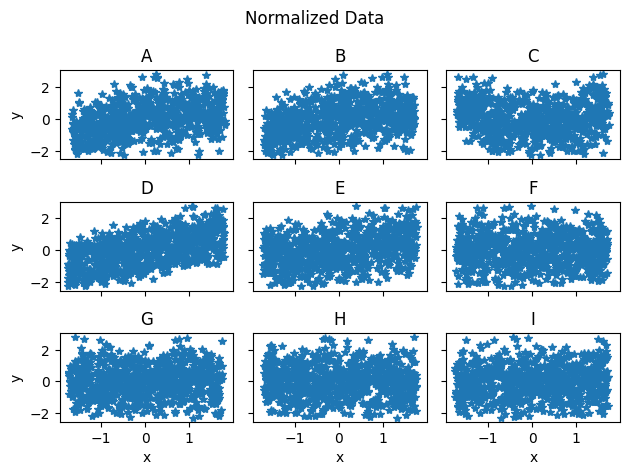

In [4]:
# Visualize the data using a mosaic plot
mosaic = [["A", "B", "C"], ["D", "E", "F"], ["G", "H", "I"]]
fig, axdict = plt.subplot_mosaic(mosaic, sharex=True, sharey=True)
# Loop over all the labels in the mosaic
for idx, ilabel in enumerate(axdict.keys()):
    axdict[ilabel].plot(x_train[:, idx], y_train, marker="*", linestyle="None")
    # Set some plot labels
    axdict[ilabel].set_title(ilabel)
    if ilabel in ["A", "D", "G"]:
        axdict[ilabel].set_ylabel("y")
    if ilabel in ["G", "H", "I"]:
        axdict[ilabel].set_xlabel("x")

fig.suptitle("Normalized Data")
fig.tight_layout()
plt.show()

## Create the dataloaders

In [5]:
from torch.utils.data import DataLoader, TensorDataset
import torch

batch_size = 32

# Create the data loader for training/validation (the test set is held separate from model training)
dataset = TensorDataset(
    torch.from_numpy(x_train).float(), torch.from_numpy(y_train).float()
)
dataset_val = TensorDataset(
    torch.from_numpy(x_val).float(), torch.from_numpy(y_val).float()
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
dataloader_val = DataLoader(
    dataset_val, batch_size=batch_size, shuffle=True, pin_memory=True
)

## Initialize Ray tuner

In [6]:
import os
import ray

ray_path = os.path.abspath(os.path.join("outdata", "ray_results"))
os.makedirs(ray_path, exist_ok=True)

model_save_dir = os.path.abspath(os.path.join("outdata", "ensemble_results"))
os.makedirs(model_save_dir, exist_ok=True)

ray.shutdown()  # just in case we are running this cell multiple times
ray.init(storage=f"file://{ray_path}")

2025-07-31 12:04:26,159	INFO worker.py:1740 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Python version:,3.11.0
Ray version:,2.22.0
Dashboard:,http://127.0.0.1:8265


(train_model pid=82960) /Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
(train_model pid=82960)   warnings.warn(warn_msg)
(train_model pid=82960) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41/train_model_3d1bbfe5_1_act_fun_idx=0,arch_type=ann,cooldown=100,device=cpu,early_stop_patience=1000,early_stop_tol=0.0001,epochs=1_2025-07-31_12-04-41/checkpoint_000000)
(train_model pid=82960) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41/train_model_3d1bbfe5_1_act_fun_idx=0,arch_type=ann,cooldown=100,device=cpu,early_stop_patience=1000,early_stop_tol=0.0001,epochs=1_2025-07

(train_model pid=82960) Saving model: model_3d1bbfe5 ...
(train_model pid=82960) Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_3d1bbfe5.pkl
(train_model pid=82960) Checkpointing at epoch: 0
(train_model pid=82960) Saving model: model_3d1bbfe5 ...
(train_model pid=82960) Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_3d1bbfe5.pkl
(train_model pid=82960) Checkpointing at epoch: 1
(train_model pid=82960) Saving model: model_3d1bbfe5 ...
(train_model pid=82960) Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_3d1bbfe5.pkl
(train_model pid=82960) Checkpointing at epoch: 2
(train_model pid=82960) Saving model: model_3d1bbfe5 ...
(train_model pid=82960) Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_3d1bbfe5.pkl
(train_model pid=82960) Checkpointing at epoch: 3
(train_model pid=82960) Saving model: mo

(train_model pid=82960) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41/train_model_3d1bbfe5_1_act_fun_idx=0,arch_type=ann,cooldown=100,device=cpu,early_stop_patience=1000,early_stop_tol=0.0001,epochs=1_2025-07-31_12-04-41/checkpoint_000005)
(train_model pid=82960) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41/train_model_3d1bbfe5_1_act_fun_idx=0,arch_type=ann,cooldown=100,device=cpu,early_stop_patience=1000,early_stop_tol=0.0001,epochs=1_2025-07-31_12-04-41/checkpoint_000006)
(train_model pid=82960) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41/train_model_3d1bbfe5_1_act_fun_idx=0,arch_type=ann,cooldown=100,devic

...

(train_model pid=83766) Saving model: model_f819c740 ... [repeated 27x across cluster]
(train_model pid=83766) Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_f819c740.pkl [repeated 27x across cluster]
(train_model pid=83766) Checkpointing at epoch: 332 [repeated 27x across cluster]


(train_model pid=83766) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41/train_model_f819c740_95_act_fun_idx=2,arch_type=ann,cooldown=100,device=cpu,early_stop_patience=1000,early_stop_tol=0.0001,epochs=_2025-07-31_12-09-05/checkpoint_000016) [repeated 27x across cluster]
(train_model pid=83769) /Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
(train_model pid=83769)   warnings.warn(warn_msg)
(train_model pid=83782) /Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
(train_model pid=83782)   warnings.warn(warn_msg)
(train_

(train_model pid=83854) Saving model: model_6f0c9e94 ... [repeated 9x across cluster]
(train_model pid=83854) Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_6f0c9e94.pkl [repeated 9x across cluster]
(train_model pid=83854) Checkpointing at epoch: 0 [repeated 9x across cluster]


(train_model pid=83769) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41/train_model_b2133246_96_act_fun_idx=2,arch_type=ann,cooldown=100,device=cpu,early_stop_patience=1000,early_stop_tol=0.0001,epochs=_2025-07-31_12-09-08/checkpoint_000016) [repeated 3x across cluster]
(train_model pid=83859) /Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
(train_model pid=83859)   warnings.warn(warn_msg)


(train_model pid=83769) Saving model: model_b2133246 ... [repeated 3x across cluster]
(train_model pid=83769) Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_b2133246.pkl [repeated 3x across cluster]
(train_model pid=83769) Checkpointing at epoch: 946 [repeated 3x across cluster]


In [7]:
# Put the large objects into the Ray object store so they can be shared across tasks
dl_train_id = ray.put(dataloader)
dl_val_id = ray.put(dataloader_val)

x_val_id = ray.put(x_val)
y_val_id = ray.put(y_val_real)
y_normalizer_id = ray.put(y_normalizer)

## Create functions for hyperparameter tuning

* model_builder(config): build a NN model using the configurations provided in the dictionary
* train_model(config): trains a NN model based on the configurations provided
* save_model_checkpoint(): save a given model with performance metrics to ensemble_results folder

1. Ray Tune will call `train_model(config)` with different configurations based on the tuning process.
2. `train_model(config)` function will call `model_builder(config)` function to build the model, then will train the model
3. Periodically, `train_model` will call `save_model_checkpoint` to log performance of surviving models.

In this notebook we will be using `pt-melt` to supply the NN models which can be initialized with a set of hyperparameters. But you can use any NN architecture that you like.

In [8]:
from ptmelt.models import ArtificialNeuralNetwork, ResidualNeuralNetwork
from ray import train
import os
import json
import tempfile
import pandas as pd
import time
from pathlib import Path
import ray
import torch
from torch import optim
from torch.optim import lr_scheduler
from ptmelt.nn_utils import get_loss_fn
from ray.air import session


def save_model_checkpoint(model, model_dir, model_name, metrics):
    """Save model weights and performance metrics."""
    os.makedirs(model_dir, exist_ok=True)

    # Set model path and save
    model_path = os.path.abspath(os.path.join(model_dir, f"{model_name}.pkl"))
    torch.save(model.state_dict(), model_path)
    print(f"Model saved at {model_path}")

    # Set path for model metadata CSV
    csv_path = os.path.abspath(os.path.join(model_dir, "model_metadata.csv"))
    # Convert metrics dictionary into a DataFrame
    df = pd.DataFrame([metrics])

    # Save or append to CSV if it exists
    if os.path.exists(csv_path):
        df.to_csv(csv_path, mode="a", header=False, index=False)
    else:
        df.to_csv(csv_path, index=False)


def model_builder(config):
    """
    Build a model with the given configuration dictionary. Useful for hyperparameter
    tuning.

    Args:
        config (dict): Dictionary containing the configuration of the model.
    """
    # ----------
    # Get all the specific configurations needed to build your model
    # ----------

    # Get random seed for reproducibility
    seed = config.get("seed", -1)
    if seed < 0:
        seed = int.from_bytes(os.urandom(4), "big")

    # Standard set of inputs for pt-melt models
    arch_type = config["arch_type"]
    num_features = config["num_features"]
    num_outputs = config["num_outputs"]
    act_fun = config.get("act_fun", "relu")
    dropout = config.get("dropout", 0.0)
    input_dropout = config.get("input_dropout", 0.0)
    batch_norm = config.get("batch_norm", False)
    batch_norm_type = config.get("batch_norm_type", "ema")
    use_batch_renorm = config.get("use_batch_renorm", False)
    output_activation = config.get("output_activation", None)
    initiliazer = config.get("initializer", "glorot_uniform")
    l1_reg = config.get("l1_reg", 0.0)
    l2_reg = config.get("l2_reg", 0.0)
    num_mixtures = config.get("num_mixtures", 0)

    # Configurations for the model size
    depth = config.get("depth", 4)
    layers_per_block = config.get("layers_per_block", 2)
    node_list = config.get("node_list", None)
    max_depth = config.get("max_depth", None)

    # Define the node_list based on config input
    node_list = []

    # Make max_depth blocks of layers_per_block depth each
    # Layer width is passed in as layer_{i}_width in the config
    for i in range(max_depth * layers_per_block):
        layer_width = config.get(f"layer_{i}_width", 0)
        layer_width = 2**layer_width if layer_width > 0 else 0  # Width = 2^layer_width
        if layer_width > 0:
            node_list.append(layer_width)
            node_list.append(layer_width)

    # Remove layers with zero widths just in case
    node_list = [x for x in node_list if x > 0]

    # Final configurations for the training
    learning_rate = config["learning_rate"]
    loss_fn = config["loss_fn"]

    if arch_type == "ann":
        model = ArtificialNeuralNetwork(
            num_features=num_features,
            num_outputs=num_outputs,
            act_fun=act_fun,
            dropout=dropout,
            input_dropout=input_dropout,
            batch_norm=batch_norm,
            batch_norm_type=batch_norm_type,
            use_batch_renorm=use_batch_renorm,
            output_activation=output_activation,
            initializer=initiliazer,
            l1_reg=l1_reg,
            l2_reg=l2_reg,
            num_mixtures=num_mixtures,
            depth=depth,
            node_list=node_list,
            seed=seed,
        )
    elif arch_type == "resnet":
        model = ResidualNeuralNetwork(
            num_features=num_features,
            num_outputs=num_outputs,
            act_fun=act_fun,
            dropout=dropout,
            input_dropout=input_dropout,
            batch_norm=batch_norm,
            batch_norm_type=batch_norm_type,
            use_batch_renorm=use_batch_renorm,
            output_activation=output_activation,
            initializer=initiliazer,
            l1_reg=l1_reg,
            l2_reg=l2_reg,
            num_mixtures=num_mixtures,
            depth=depth,
            layers_per_block=layers_per_block,
            node_list=node_list,
            seed=seed,
        )

    # Build the model
    model.build()

    # Create optimier and loss scheduler
    optimizer = getattr(optim, "Adam")(model.parameters(), lr=learning_rate)
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=config.get("patience", 10),
        factor=config.get("factor", 0.1),
        threshold=config.get("threshold", 1e-4),
        cooldown=config.get("cooldown", 0),
        min_lr=config.get("min_lr", 1e-6),
    )
    criterion = get_loss_fn(loss_fn)

    return model, optimizer, criterion


def train_model(
    config,
    model_save_dir,
    act_fun_mapping,
    report_frequency,
    n_checkpoint=500,
    gpu_avail=False,
    device="cpu",
):
    """Builds the model, trains the model, and reports results to Ray Tune."""

    # Get the train and val datasets from ray
    dl_train = ray.get(dl_train_id)
    dl_val = ray.get(dl_val_id)

    # Set the activation function based on the index
    config["act_fun"] = act_fun_mapping[config["act_fun_idx"]]
    model, optimizer, criterion = model_builder(config)

    start_time = time.time()

    # Initialize tracking variables
    best_epoch = 0
    best_val_loss = float("inf")

    # Create history dictionary
    model.history = {
        "loss": [],
        "val_loss": [],
        "best_val_loss": [],
        "best_epoch": [],
        "training_time": [],
    }

    # Get the current epoch from Ray Tune checkpoint if it exists
    current_epoch = 0
    # Checkpoint could exist if Ray Tune is resuming training after pausing
    if train.get_checkpoint():
        with train.get_checkpoint().as_directory() as checkpoint_dir:
            current_epoch = int((Path(checkpoint_dir) / "data.ckpt").read_text())

    # Get the trial ID
    trial_id = session.get_trial_id()

    # Train over the defined number of epochs
    # If the current epoch is not zero, we are resuming training from a checkpoint
    # so we start from the current epoch
    for epoch in range(current_epoch, config["epochs"]):
        # Training step
        train_loss = model.step(dl_train, optimizer, criterion, device, training=True)
        # Validation step (training is false for evaluation mode)
        val_loss = model.step(dl_val, optimizer, criterion, device, training=False)

        # Keep track of best validation loss and epoch
        if val_loss < best_val_loss:
            best_epoch = epoch + 1
            best_val_loss = val_loss

        training_time = time.time() - start_time

        # Update history
        model.history["loss"].append(train_loss)
        model.history["val_loss"].append(val_loss)
        model.history["best_val_loss"].append(best_val_loss)
        model.history["best_epoch"].append(best_epoch)
        model.history["training_time"].append(training_time)

        # Periodically checkpoint the model (will be used later for Ensemble UQ !!!)
        # if (epoch + 1) % (n_checkpoint) == 0 or (epoch + 1) == config["epochs"]:
        # if (epoch + 1) == best_epoch or (epoch + 1) == config["epochs"]:
        if (epoch + 1) == best_epoch:
            # Get the model name using the trial ID
            model_name = f"model_{trial_id}"
            # Get the current model config to save along with the model
            model_config = {**config, "model_name": model_name}
            # Save the metrics in a dictionary
            metrics = {
                "model_name": model_name,
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "training_time": time.time() - start_time,
            }
            print(f"Saving model: {model_name} ...")
            # Save the model checkpoint with the model name and metrics
            save_model_checkpoint(model, model_save_dir, model_name, metrics)
            # Save the config file as well so we can reproduce the model
            with open(
                os.path.join(model_save_dir, f"{model_name}_config.json"), "w"
            ) as f:
                json.dump(model_config, f)

            # Finally, checkpoint Ray Tune and report the results
            with tempfile.TemporaryDirectory() as checkpoint_dir:
                (Path(checkpoint_dir) / "data.ckpt").write_text(str(epoch))
                print(f"Checkpointing at epoch: {epoch}")  # Debug statement
                session.report(
                    {
                        "iterations": epoch + 1,
                        "train_loss": model.history["loss"][-1],
                        "val_loss": model.history["val_loss"][-1],
                        "best_epoch": best_epoch,
                        "best_val_loss": best_val_loss,
                        "training_time": training_time,
                        "checkpoint_epoch": epoch,
                    },
                    checkpoint=session.Checkpoint.from_directory(checkpoint_dir),
                )

        # Report the results to Ray Tune every report_frequency epochs
        elif (epoch + 1) % (report_frequency) == 0:
            session.report(
                {
                    "iterations": epoch + 1,
                    "train_loss": model.history["loss"][-1],
                    "val_loss": model.history["val_loss"][-1],
                    "best_epoch": best_epoch,
                    "best_val_loss": best_val_loss,
                    "training_time": training_time,
                    "checkpoint_epoch": None,  # No checkpoint this time
                }
            )

# Quick Sanity Check

In [9]:
# test
import time
from torchinfo import summary

device = torch.device("cpu")

base_configs = {
    "loss_fn": "mse",
    "num_features": x_train.shape[1],
    "num_outputs": y_train.shape[1],
    "layers_per_block": 2,
    "max_depth": 2,
    "batch_norm": False,
    "dropout": 0.0,
    "input_dropout": 0.0,
    "lr_scheduler": "plateau",
}

tune_configs = {
    "arch_type": "ann",
    "learning_rate": 1e-3,
    "act_fun": "relu",
    "l2_reg": 1e-6,
    "layer_0_width": 4,  # This expands to [16, 16]
    "layer_1_width": 4,  # This expands to [16, 16]
}

initial_configs = {**base_configs, **tune_configs}

model, optimizer, crit = model_builder(initial_configs)
print(summary(model, input_size=(batch_size, x_train.shape[1]), device=device))
print(model.layer_dict)

Layer (type:depth-idx)                   Output Shape              Param #
ArtificialNeuralNetwork                  [32, 1]                   --
├─ModuleDict: 1-1                        --                        --
│    └─DenseBlock: 2-1                   [32, 16]                  --
│    │    └─ModuleDict: 3-1              --                        992
│    └─DefaultOutput: 2-2                [32, 1]                   --
│    │    └─Linear: 3-2                  [32, 1]                   17
│    │    └─Identity: 3-3                [32, 1]                   --
Total params: 1,009
Trainable params: 1,009
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.00
Estimated Total Size (MB): 0.02
ModuleDict(
  (output): DefaultOutput(
    (output_layer): Linear(in_features=16, out_features=1, bias=True)
    (activation_layer): Identity()
  )
  (dense_block): DenseBlock(
    (layer_dict): ModuleDict(
    

In [10]:
s_time = time.time()

model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=crit,
    num_epochs=1000,
    device=device,
    verbose=True,
)

# Save the model
model_name = "test_model"
model_dir = os.path.join("outdata/test_model", model_name)
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.abspath(os.path.join(model_dir, f"{model_name}.pkl"))
torch.save(model.state_dict(), model_path)
print(f"Model saved at {model_path}")

print(f"Elapsed time: {time.time() - s_time}")

  0%|          | 0/1000 [00:00<?, ?it/s]/Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
  1%|          | 7/1000 [00:00<00:15, 62.31it/s]

Epoch 10, Loss: 0.2662, Val Loss: 0.2400


  2%|▏         | 23/1000 [00:00<00:13, 73.48it/s]

Epoch 20, Loss: 0.1745, Val Loss: 0.1685


  3%|▎         | 31/1000 [00:00<00:12, 74.78it/s]

...

Epoch 980, Loss: 0.0050, Val Loss: 0.1040


100%|█████████▉| 995/1000 [00:12<00:00, 80.11it/s]

Epoch 990, Loss: 0.0055, Val Loss: 0.1590


100%|██████████| 1000/1000 [00:12<00:00, 78.94it/s]

Epoch 1000, Loss: 0.0051, Val Loss: 0.1112
Model saved at /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/test_model/test_model/test_model.pkl
Elapsed time: 12.685479879379272


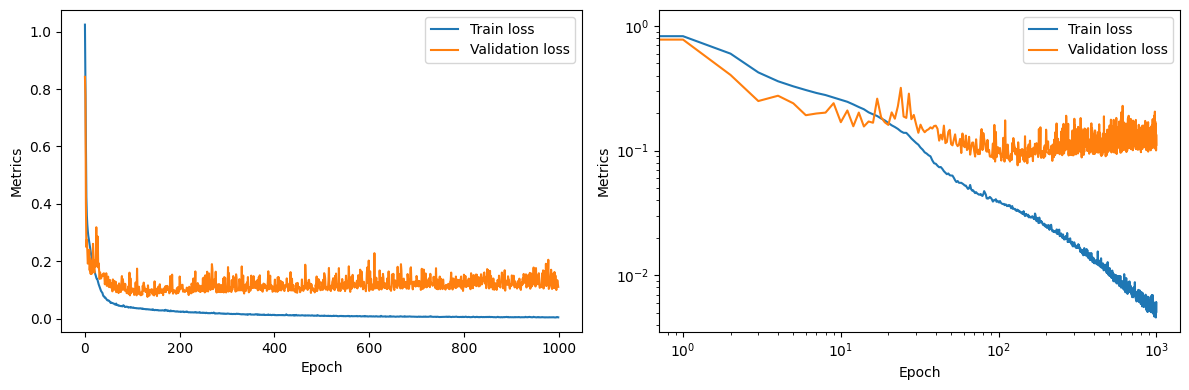

In [11]:
from ptmelt.utils.visualization import plot_history

history = model.history
plot_history(history, plot_log=True)

In [12]:
from ptmelt.utils.evaluation import make_predictions

# Evaluate the model performance on train, validation, and test data
pred_train = make_predictions(
    model, x_train, y_normalizer=y_normalizer, unnormalize=True
)
pred_val = make_predictions(model, x_val, y_normalizer=y_normalizer, unnormalize=True)
pred_test = make_predictions(model, x_test, y_normalizer=y_normalizer, unnormalize=True)

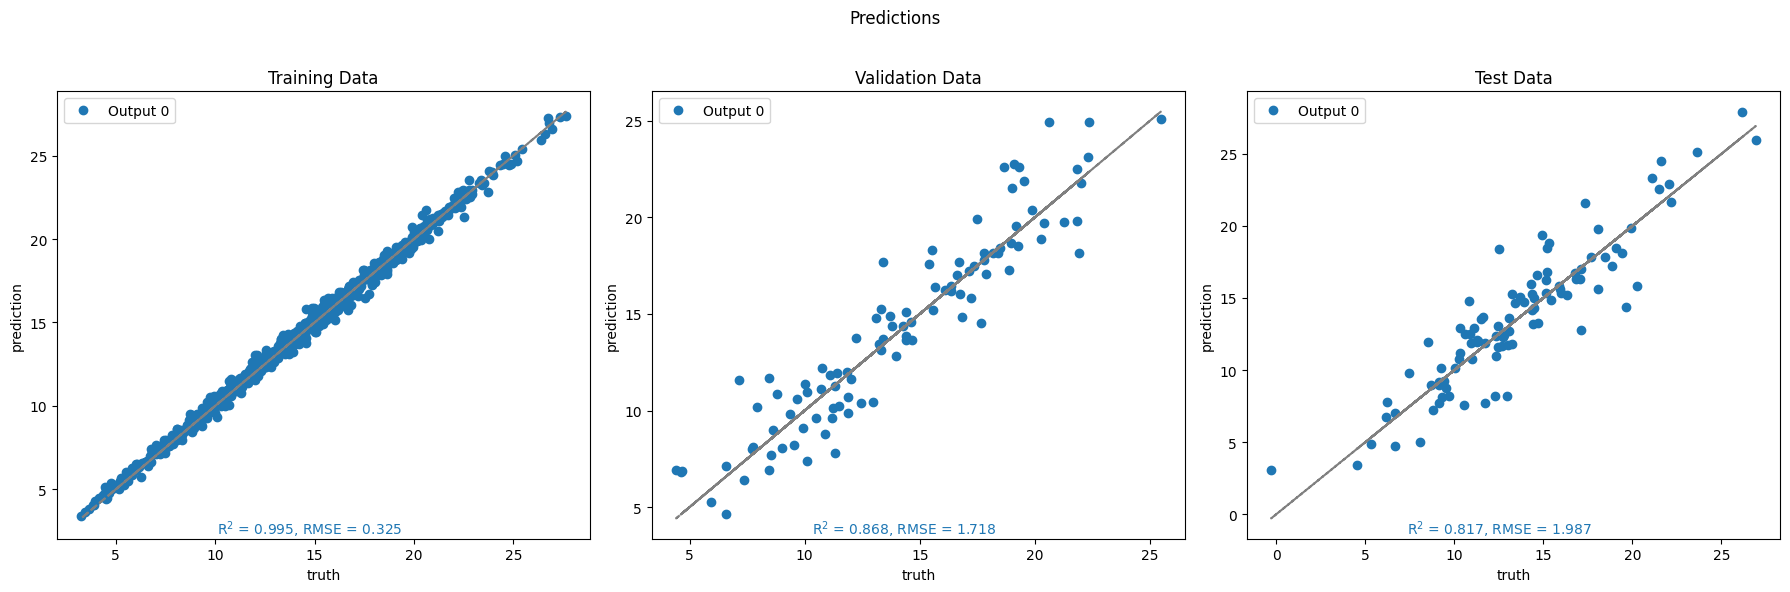

In [13]:
from ptmelt.utils.visualization import plot_predictions

# Plot the predictions
plot_predictions(pred_train, y_train_real, pred_val, y_val_real, pred_test, y_test_real)

# Set up which hyperparameters we want to tune

In [14]:
from ray import tune

# ----------
# Default Settings (not to be tuned)
max_epochs = 1000  # Maximum number of epochs to train for each trial
num_samples = 50  # Total number of combinations to run
report_frequency = 100  # Number of epochs to wait before reporting to Ray Tune
metric = "best_val_loss"  # This is the metric we want to optimize
mode = "min"  # Minimize the validation loss
sampler = "tpe"  # Tree-structured Parzen Estimator
scheduler_name = "asha"  # Asynchronous Successive Halving Algorithm
search_alg_name = "optuna"  # Optuna is the package Ray Tune uses (other options...)
reduction_factor = 4  # This is more aggressive than the default of 2
learning_rate = 1e-3  # Fixed value since we are using a scheduler (starting point)
early_stop_tol = 1e-4  # Tolerance for early stopping
early_stop_patience = 1000  # Number of epochs to wait before early stopping
threshold = 1e-4  # for lr scheduler
threshold_mode = "rel"  # for lr scheduler
cooldown = 100  # for lr scheduler
patience = 100  # for lr scheduler
factor = 0.5  # Learning rate reduction factor
brackets = 2  # Number of brackets for the ASHA scheduler
n_startup_trials = 5  # Number of trials to run before starting the ASHA scheduler
n_ei_candidates = 64  # Number of candidates for the expected improvement acquisition fn
constant_liar = True  # Constant liar for the expected improvement acquisition fn
min_lr = 1e-6  # Minimum learning rate for the scheduler
n_checkpoint = 500  # Number of epochs to wait before checkpointing the model
seed = 42
max_depth = 2  # Maximum depth of the model (number of blocks)
# batch_size = 32
gpu_avail = False
layers_per_block = 2  # Number of layers per block in the model
num_mixtures = 0  # only used for heteroscedastic models

base_configs = {
    "epochs": max_epochs,
    "max_depth": max_depth,
    "num_mixtures": num_mixtures,
    "report_frequency": report_frequency,
    "gpu_avail": gpu_avail,
    # "batch_size": batch_size,
    "learning_rate": learning_rate,
    "early_stop_tol": early_stop_tol,
    "early_stop_patience": early_stop_patience,
    "threshold": threshold,
    "threshold_mode": threshold_mode,
    "cooldown": cooldown,
    "min_lr": min_lr,
    "patience": patience,
    "factor": factor,
    "layers_per_block": layers_per_block,
    "seed": seed,
    "device": "cpu",
    "loss_fn": "mse",
    "num_features": x_train.shape[1],
    "num_outputs": y_train.shape[1],
}

# ----------
# Settings to be tuned
arch_type = ["ann", "resnet"]  # Types of architectures to tune
node_values = [0, 7]  # powers of 2: [0, 2, 4, 8, 16, 32, 64, 128, 256]
act_fun = ["relu", "leaky_relu", "tanh", "swish"]
l2_reg = [1e-6, 1e-2]

# Map activation functions to indices
act_fun_mapping = {i: act for i, act in enumerate(act_fun)}

# Set up the hyperparameter tuning configuration
tune_configs = {
    "arch_type": tune.choice(arch_type),
    "act_fun_idx": tune.randint(0, len(act_fun)),
    "l2_reg": tune.loguniform(l2_reg[0], l2_reg[1]),
    **{
        f"layer_{i}_width": tune.randint(min(node_values), max(node_values) + 1)
        for i in range(max_depth)
    },
}

total_configs = {**base_configs, **tune_configs}

## Set up some expert choices to seed the optimization

This is optional, but I have found that it helps speed up the hyperparameter tuning process and allow for smaller number of samples. These can come from hand tuning or just intuition.

Here I am using 4 "expert" configurations, but these are not likely to be optimal...

You should experiment with what baselines are useful for your datasets!

In [15]:
# Set up a couple of "expert picks" for a baseline
baselines = [
    {
        "arch_type": "ann",
        "act_fun_idx": 0,  # relu
        "l2_reg": 1e-6,
        "layer_0_width": 4,
        "layer_1_width": 4,
    },
    {
        "arch_type": "resnet",
        "act_fun_idx": 0,  # relu
        "l2_reg": 1e-6,
        "layer_0_width": 4,
        "layer_1_width": 4,
    },
    {
        "arch_type": "ann",
        "act_fun_idx": 1,  # leaky_relu
        "l2_reg": 1e-4,
        "layer_0_width": 5,
        "layer_1_width": 5,
    },
    {
        "arch_type": "resnet",
        "act_fun_idx": 1,  # leaky_relu
        "l2_reg": 1e-4,
        "layer_0_width": 5,
        "layer_1_width": 5,
    },
]

## Set up the Optuna Search

In [16]:
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler
import optuna
from ray.tune.search.concurrency_limiter import ConcurrencyLimiter

# Limit to number of concurrent trials (Change based on resources!!)
max_concurrent = 10

# Set up the search algorithm and scheduler
search_alg = OptunaSearch(
    metric=metric,
    mode=mode,
    sampler=(
        optuna.samplers.TPESampler(
            multivariate=True,
            group=True,
            n_startup_trials=n_startup_trials,
            n_ei_candidates=n_ei_candidates,
            constant_liar=constant_liar,
            seed=seed,
        )
    ),
    points_to_evaluate=baselines,  # Make sure that we start with the expert picks
)
search_alg = ConcurrencyLimiter(
    search_alg,
    max_concurrent=max_concurrent,  # Safety to not exceed resources
)
# ASHAScheduler for early stopping
scheduler = ASHAScheduler(
    metric=metric,
    mode=mode,
    max_t=max_epochs,
    grace_period=1,  # Number of reports to wait before stopping a trial
    reduction_factor=reduction_factor,
    brackets=brackets,
)

/Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/Users/nwimer/miniconda3/envs/nrel-ai/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(


## Initialize the tuner

In [ ]:
from ray.air import RunConfig
from datetime import datetime
from ray import tune

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

num_samples = 100  # 100 runs will take about 3-5 minutes on macbook pro M3

# Set up the Ray Tune configuration parameters (separate from the model config)
tune_config_params = {
    "num_samples": num_samples,  # Total number of combinations to run
    "scheduler": scheduler,  # ASHA scheduler for early stopping
    "search_alg": search_alg,  # Optuna search algorithm
}

tuner = tune.Tuner(  # The Ray Tuner class
    tune.with_resources(  # Using the resource specified below
        tune.with_parameters(  # Pass the train_model function with parameters per task
            train_model,
            model_save_dir=model_save_dir,
            gpu_avail=gpu_avail,
            act_fun_mapping=act_fun_mapping,
            report_frequency=report_frequency,
            n_checkpoint=n_checkpoint,
            device="cpu",
        ),
        resources={"cpu": 1, "gpu": 0},  # Number of resources per trial (can be < 1)
    ),
    tune_config=tune.TuneConfig(**tune_config_params),  # Tuner configs
    param_space=total_configs,  # The hyperparameter space to search (model configs)
    run_config=RunConfig(  # For Ray Tune to save tuning data
        name=f"model_tuning_{timestamp}",
        storage_path=ray_path,
    ),
)

In [18]:
results = tuner.fit()

2025-07-31 12:09:27,012	WARNING experiment_state.py:205 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this error by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0).
2025-07-31 12:09:27,048	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ray_results/model_tuning_2025-07-31_12-04-41' in 0.0519s.
2025-07-31 12:09:27,059	INFO tune.py:1039 -- Total run time: 285.17 seconds (285.09 seconds for the tuning loop).


# Examine the Hyperparameter Tuning results

Now that the tuning is complete, we can gain some insight into our method.

In [19]:
from pprint import pprint

dfs = {result.path: result.metrics_dataframe for result in results}

# Get the best result based on the validation loss
best_result = results.get_best_result(metric="best_val_loss", mode="min")
best_config = best_result.config

print("Best hyperparameters found were: ")
pprint(best_result.config)
print("Best Val Loss:", best_result.metrics["best_val_loss"])
print(
    "Validation loss:",
    best_result.metrics["best_val_loss"],
    "at epoch:",
    best_result.metrics["best_epoch"],
)
print("Training loss:", best_result.metrics["train_loss"])

# Save the complete results
results_df = pd.concat(dfs.values())
results_df.to_csv(os.path.join(model_save_dir, "tune_results.csv"))

Best hyperparameters found were: 
{'act_fun': 'tanh',
 'act_fun_idx': 2,
 'arch_type': 'ann',
 'cooldown': 100,
 'device': 'cpu',
 'early_stop_patience': 1000,
 'early_stop_tol': 0.0001,
 'epochs': 1000,
 'factor': 0.5,
 'gpu_avail': False,
 'l2_reg': 0.003656922319166156,
 'layer_0_width': 7,
 'layer_1_width': 5,
 'layers_per_block': 2,
 'learning_rate': 0.001,
 'loss_fn': 'mse',
 'max_depth': 2,
 'min_lr': 1e-06,
 'num_features': 10,
 'num_mixtures': 0,
 'num_outputs': 1,
 'patience': 100,
 'report_frequency': 100,
 'seed': 42,
 'threshold': 0.0001,
 'threshold_mode': 'rel'}
Best Val Loss: 0.03500231774523854
Validation loss: 0.03500231774523854 at epoch: 333
Training loss: 0.08466547012329101


## Validation Loss across different runs

Plot the validation loss curves for the different runs in the HP tuning to examine performance.

Here, we will look at several runs from each category:

- runs that were terminated at 100 epochs
- runs that were terminated at 300 epochs
- runs that were terminated at 900 epochs
- runs that survived until the end of the hyperparameter training at 1,000 epochs

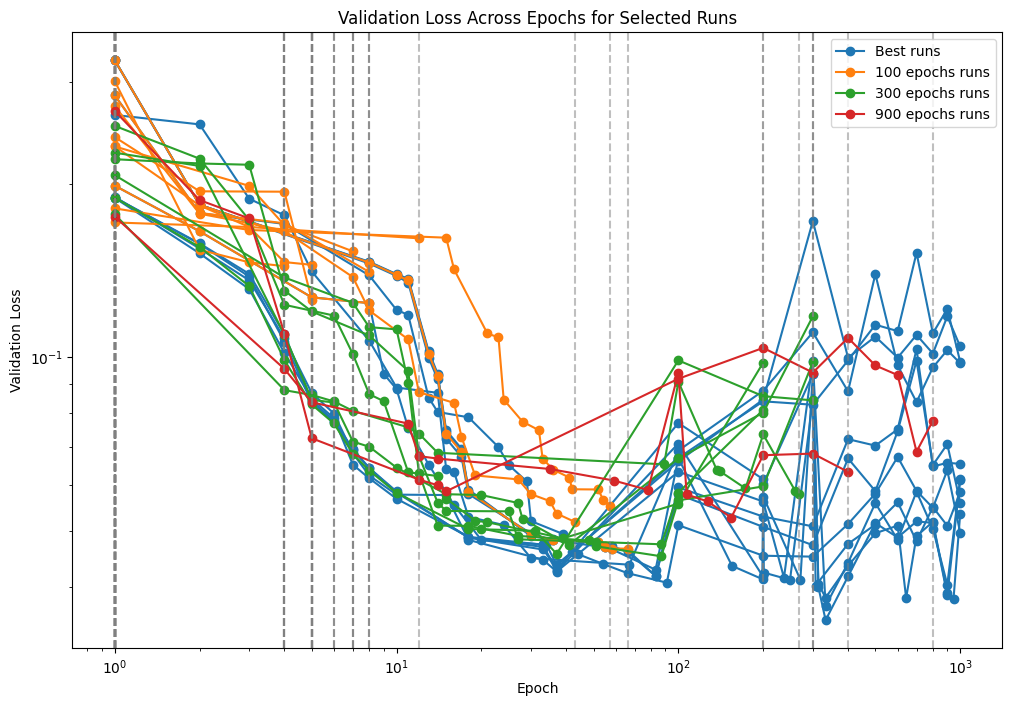

In [20]:
def plot_val_loss_across_epochs(
    tune_results_path, num_runs=2, intervals=[100, 300, 900]
):
    # Load the results from CSV
    df = pd.read_csv(tune_results_path, dtype={"trial_id": str})

    # Get only the last iteration of each trial (final hyperparameter values & best score)
    df_trials = df.groupby("trial_id").last().reset_index()

    # Sort by best_score to see best-performing trials first
    df_trials = df_trials.sort_values(by="best_val_loss")

    # Select the best runs
    best_runs = df_trials.head(num_runs)

    # Select runs terminated at different intervals
    runs_1 = df_trials[df_trials["iterations"] <= intervals[0]].head(num_runs)
    runs_2 = df_trials[
        (df_trials["iterations"] > intervals[0])
        & (df_trials["iterations"] <= intervals[1])
    ].head(num_runs)
    runs_3 = df_trials[
        (df_trials["iterations"] > intervals[1])
        & (df_trials["iterations"] <= intervals[2])
    ].head(num_runs)

    # Get the trial_ids for the selected runs
    selected_trial_ids = pd.concat([best_runs, runs_1, runs_2, runs_3])[
        "trial_id"
    ].unique()

    # Filter the original dataframe to get the full trajectories for the selected runs
    df_selected = df[df["trial_id"].isin(selected_trial_ids)]

    # Plot val_loss across epochs for selected runs
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, (runs, color, label) in enumerate(
        zip(
            [best_runs, runs_1, runs_2, runs_3],
            ["C0", "C1", "C2", "C3", "C4"],
            [
                "Best runs",
                f"{intervals[0]} epochs runs",
                f"{intervals[1]} epochs runs",
                f"{intervals[2]} epochs runs",
            ],
        )
    ):
        for trial_id in runs["trial_id"]:
            run = df_selected[df_selected["trial_id"] == trial_id]
            ax.plot(
                run["iterations"].values,
                run["val_loss"].values,
                color=color,
                marker="o",
                label=label if trial_id == runs["trial_id"].iloc[0] else "",
            )

    # Add vertical lines for early stopped runs
    for _, run in df_trials.iterrows():
        if run["iterations"] < intervals[-1]:
            ax.axvline(x=run["iterations"], color="gray", linestyle="--", alpha=0.5)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.legend()
    plt.title("Validation Loss Across Epochs for Selected Runs")
    plt.show()


plot_val_loss_across_epochs(
    os.path.join(model_save_dir, "tune_results.csv"),
    num_runs=10,  # number of runs from each interval to plot
    intervals=[100, 300, 900],
)

## Hyperparameter correlation plot

Let's see which hyperparameters are most correlated to a low validation loss...

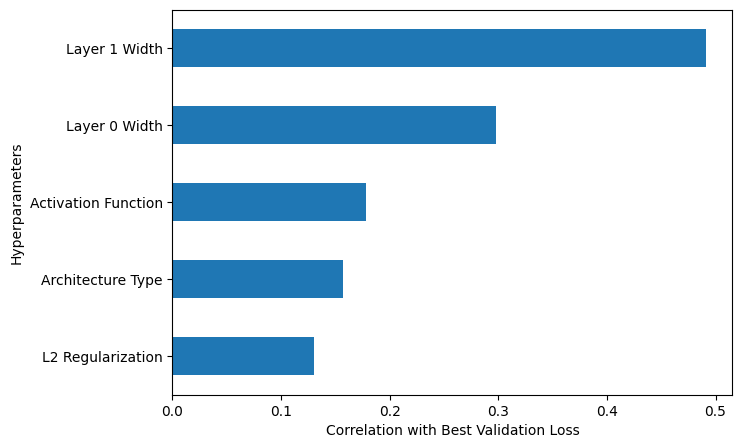

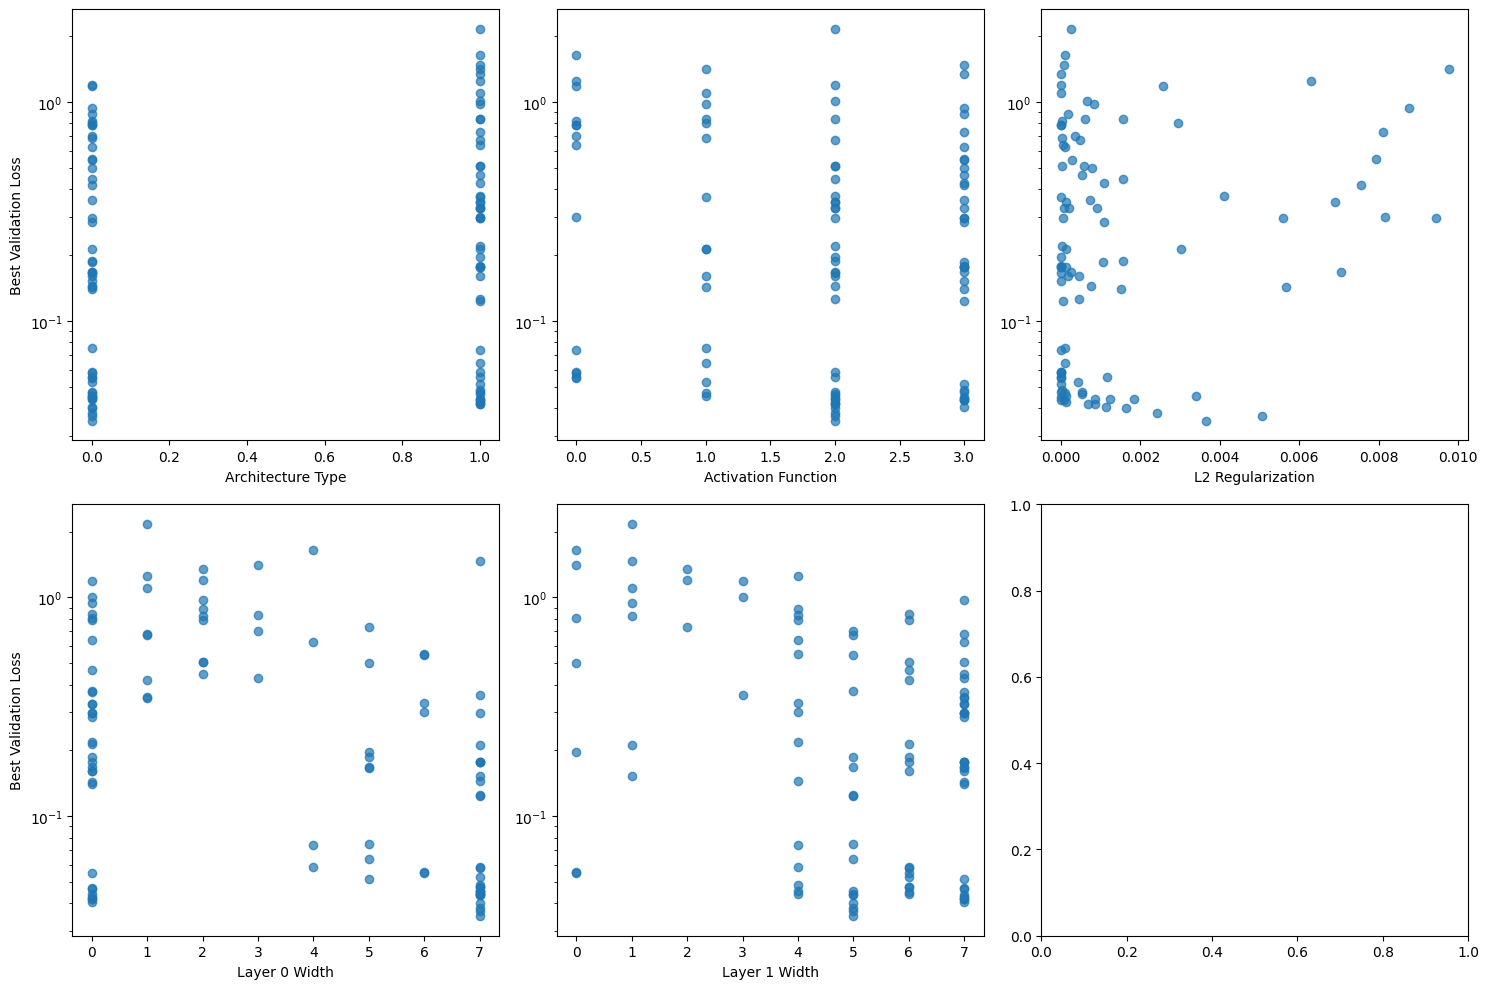

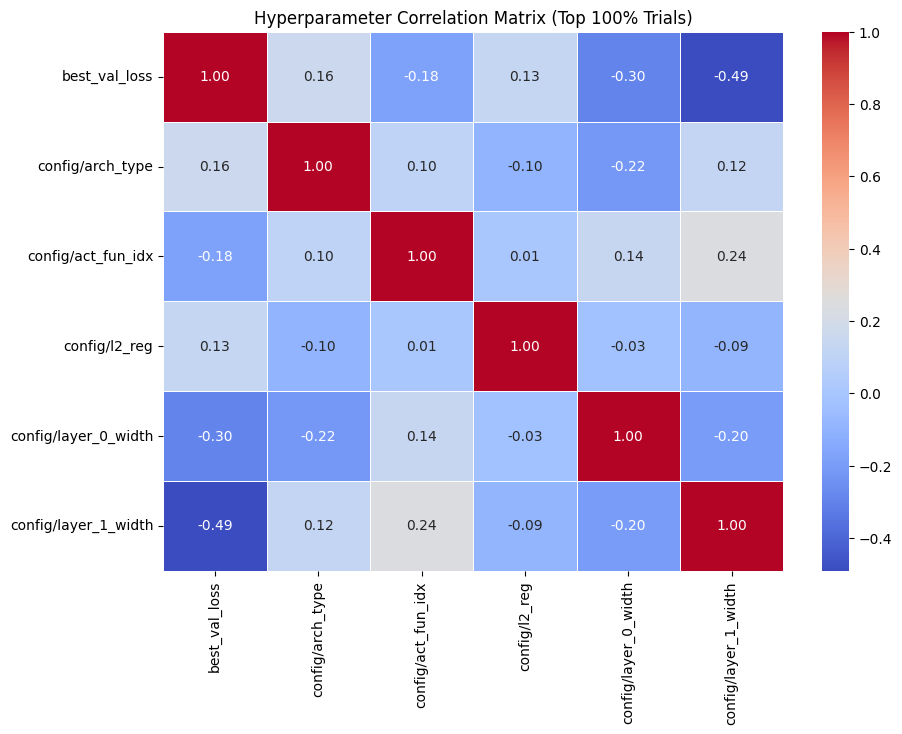

In [21]:
import seaborn as sns


def plot_hyperparameter_tuning_results(
    tune_results_path,
    top_percent=25,  # Percentage of top-performing trials to consider for plotting
    hyperparam_dict=None,  # Dict mapping hyperparameter names to labels
):
    if hyperparam_dict is None:
        print(f"No hyperparameters provided. Exiting.")
        return

    hyperparams = list(hyperparam_dict.keys())

    # Load the results from CSV
    df = pd.read_csv(tune_results_path, dtype={"trial_id": str})

    # Get only the last iteration of each trial (final hyperparameter values & best score)
    df_trials = df.groupby("trial_id").last().reset_index()

    # Convert trial_id to string for plotting
    df_trials["trial_id"] = df_trials["trial_id"].astype(str)
    df_trials = df_trials[["trial_id", "best_val_loss"] + hyperparams]

    # Convert the arch_type to a categorical variable and map to integers
    if "config/arch_type" in df_trials.columns:
        df_trials["config/arch_type"] = df_trials["config/arch_type"].astype("category")
        df_trials["config/arch_type"] = df_trials["config/arch_type"].cat.codes

    # Sort by best_score to see best-performing trials first
    df_trials = df_trials.sort_values(by="best_val_loss")

    # Select the top_percent best-performing models
    top_n_percent = df_trials.head(int(len(df_trials) * top_percent / 100))

    # Plot hyperparameter importance
    df_numeric = top_n_percent.drop(columns=["trial_id"])
    correlations = (
        df_numeric.corr()["best_val_loss"]
        .abs()
        .drop("best_val_loss")
        # .drop("config/act_fun_idx")
    )
    correlations.index = correlations.index.map(hyperparam_dict)

    fig, ax = plt.subplots(figsize=(8, 5))
    correlations.sort_values().plot(kind="barh", ax=ax)
    ax.set_xlabel("Correlation with Best Validation Loss")
    ax.set_ylabel("Hyperparameters")
    plt.subplots_adjust(left=0.2)

    # Plot hyperparameter vs. best score
    fig, axes = plt.subplots(
        2, np.ceil(len(hyperparams) / 2).astype(int), figsize=(15, 10)
    )
    axes = axes.flatten()
    for i, param in enumerate(hyperparams):
        hp_label = hyperparam_dict[param]
        if param == "config/learning_rate":
            axes[i].set_xscale("log")
        axes[i].set_yscale("log")
        axes[i].scatter(top_n_percent[param], top_n_percent["best_val_loss"], alpha=0.7)
        axes[i].set_xlabel(hp_label)
        if i % 3 == 0:
            axes[i].set_ylabel("Best Validation Loss")
    plt.tight_layout()

    # Plot hyperparameter correlation matrix
    correlation_matrix = df_numeric.corr()
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
    )
    plt.title(f"Hyperparameter Correlation Matrix (Top {top_percent/100:.0%} Trials)")
    plt.show()


plot_hyperparameter_tuning_results(
    os.path.join(model_save_dir, "tune_results.csv"),
    top_percent=100,
    hyperparam_dict={
        "config/arch_type": "Architecture Type",
        "config/act_fun_idx": "Activation Function",
        "config/l2_reg": "L2 Regularization",
        "config/layer_0_width": "Layer 0 Width",
        "config/layer_1_width": "Layer 1 Width",
    },
)

# act_fun = ["relu", "leaky_relu", "tanh", "swish"] -- for reference

# Form an Ensemble of best performing models

Now we can take the top N% best performing models and create an ensemble for UQ.

In [22]:
def find_best_checkpoints(df):
    best_checkpoints = df.loc[df.groupby("model_name")["best_val_loss"].idxmin()]
    return best_checkpoints


def filter_top_models(model_dir, num_models=10, unique_models=True):
    """Filter top-performing models within a threshold or select a specific number of top models."""
    csv_path = os.path.join(model_dir, "model_metadata.csv")

    # Get all of the model names in the directory
    model_names = [
        f.split(".")[0]
        for f in os.listdir(model_dir)
        if os.path.isfile(os.path.join(model_dir, f)) and f.endswith(".pkl")
    ]
    print(f"Found {len(model_names)} models in the directory")

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"No model metadata CSV found at {csv_path}")

    df = pd.read_csv(csv_path)

    # Filter out all models that are not within the current directory
    df = df[df["model_name"].isin(model_names)]
    print(f"Found {len(df)} models in the metadata file")

    if unique_models:
        # Find the best model checkpoint for each model name
        df = find_best_checkpoints(df)

    # # Find the best performing model (lowest best_score)
    # best_score = df["best_val_loss"].min()

    # if num_models is not None:
    # Select the top N models based on best_score
    filtered_models = df.nsmallest(num_models, "best_val_loss")
    print(f"Selecting top {num_models} models for the ensemble")
    return filtered_models

    # if threshold == "all":
    #     print(f"Selecting all models for the ensemble: {len(df)} models")
    #     return df
    # else:
    #     # Define the threshold for ensemble selection
    #     if best_score < 0:
    #         threshold_value = best_score * (1 - threshold / 100)
    #     else:
    #         threshold_value = best_score * (1 + threshold / 100)

    #     # Select models within 5% of the best score
    #     filtered_models = df[df["best_val_loss"] <= threshold_value]

    #     print(
    #         f"Selecting {len(filtered_models)} models for the ensemble (threshold: {threshold_value:.4f})"
    #     )

    #     return filtered_models


num_models = 20
filtered_models = filter_top_models(
    model_save_dir, num_models=num_models, unique_models=True
)
print(filtered_models)

Found 100 models in the directory
Found 674 models in the metadata file
Selecting top 20 models for the ensemble
         model_name  best_val_loss  best_epoch  training_time
661  model_f819c740       0.035002         333       5.299584
617  model_3845bee6       0.037020         333       5.140199
673  model_b2133246       0.038092         947      14.839464
354  model_ae4f9023       0.040185         307       4.795963
251  model_04cbfae6       0.040647          91       1.166447
110  model_53818beb       0.041744          83       1.167973
520  model_d9db1d44       0.041746          83       1.060140
232  model_fc5e0394       0.042811          83       1.037860
352  model_c49ddf94       0.043660          37       0.653631
318  model_1d89c13b       0.043676          67       1.217981
174  model_ef7e5922       0.043975         124       1.537637
532  model_847ae5a2       0.044064          37       0.727131
302  model_f094f531       0.044121         114       1.720913
385  model_2cfc9b50

## Loop over best performing models and evaluate predictions

Here is where you could optionally retrain each of these models to align with the best_epoch!

Instead, we are just going to use the latest checkpoint from each model for simplicity.

Loading model: model_f819c740 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_f819c740.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: ann
    l2_reg: 0.003656922319166156
    layer_0_width: 7
    layer_1_width: 5
    best epoch: 333


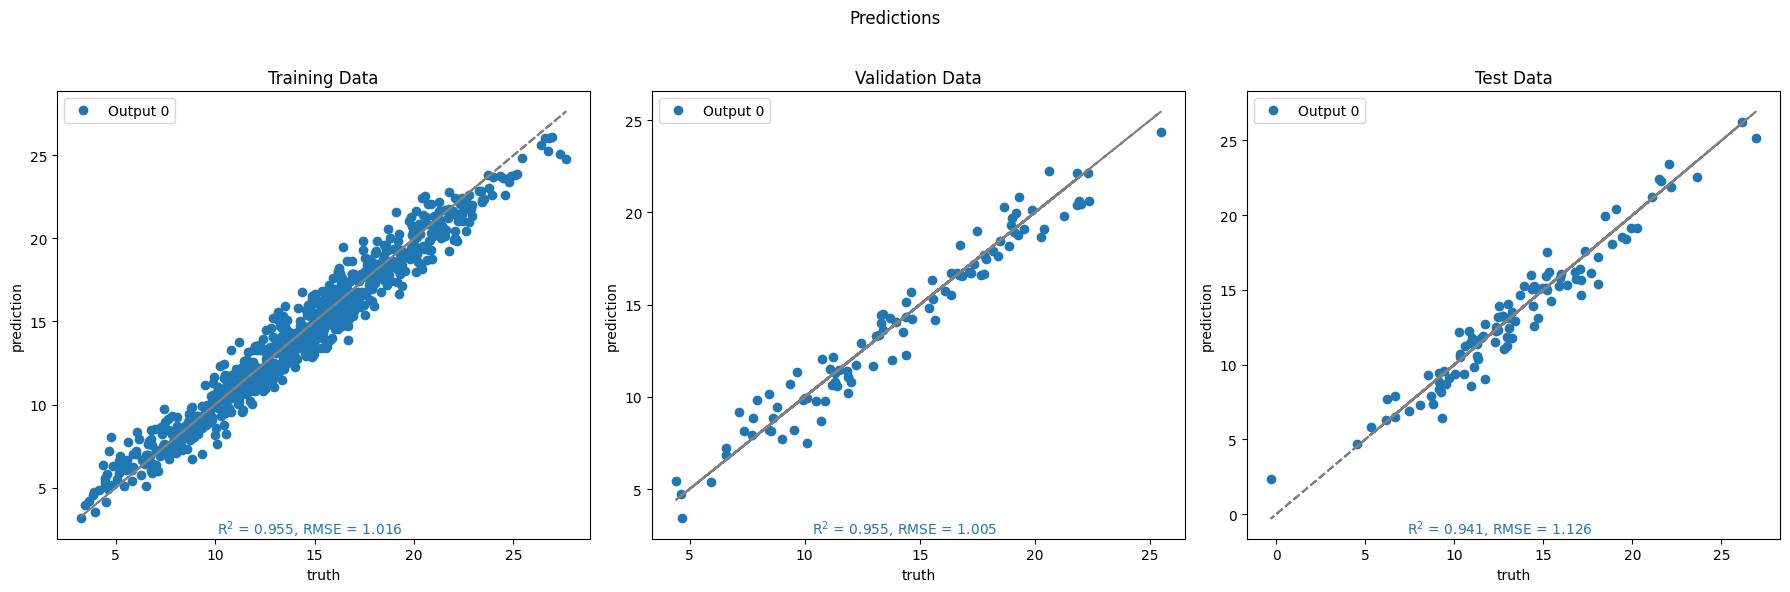

Loading model: model_3845bee6 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_3845bee6.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: ann
    l2_reg: 0.005067159635601377
    layer_0_width: 7
    layer_1_width: 5
    best epoch: 333


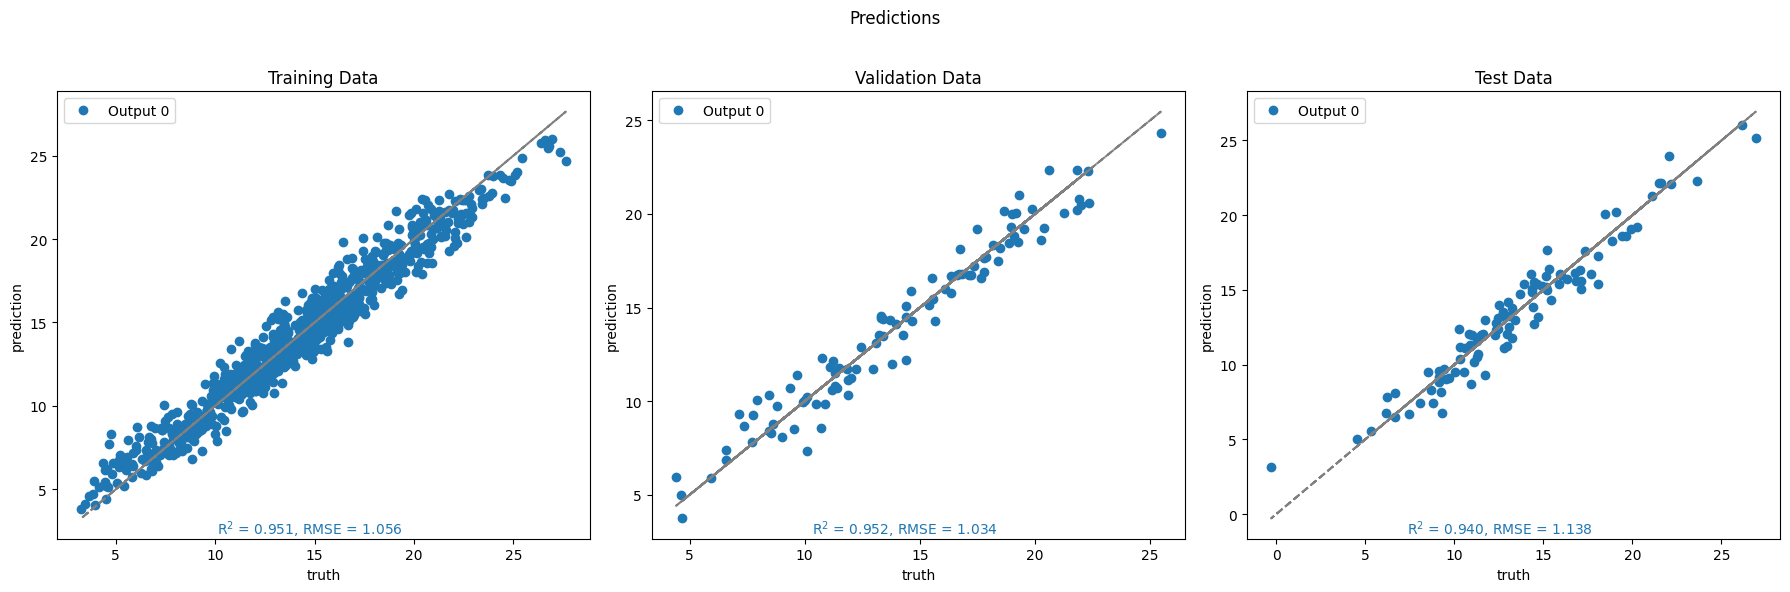

Loading model: model_b2133246 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_b2133246.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: ann
    l2_reg: 0.0024295663267798204
    layer_0_width: 7
    layer_1_width: 5
    best epoch: 947


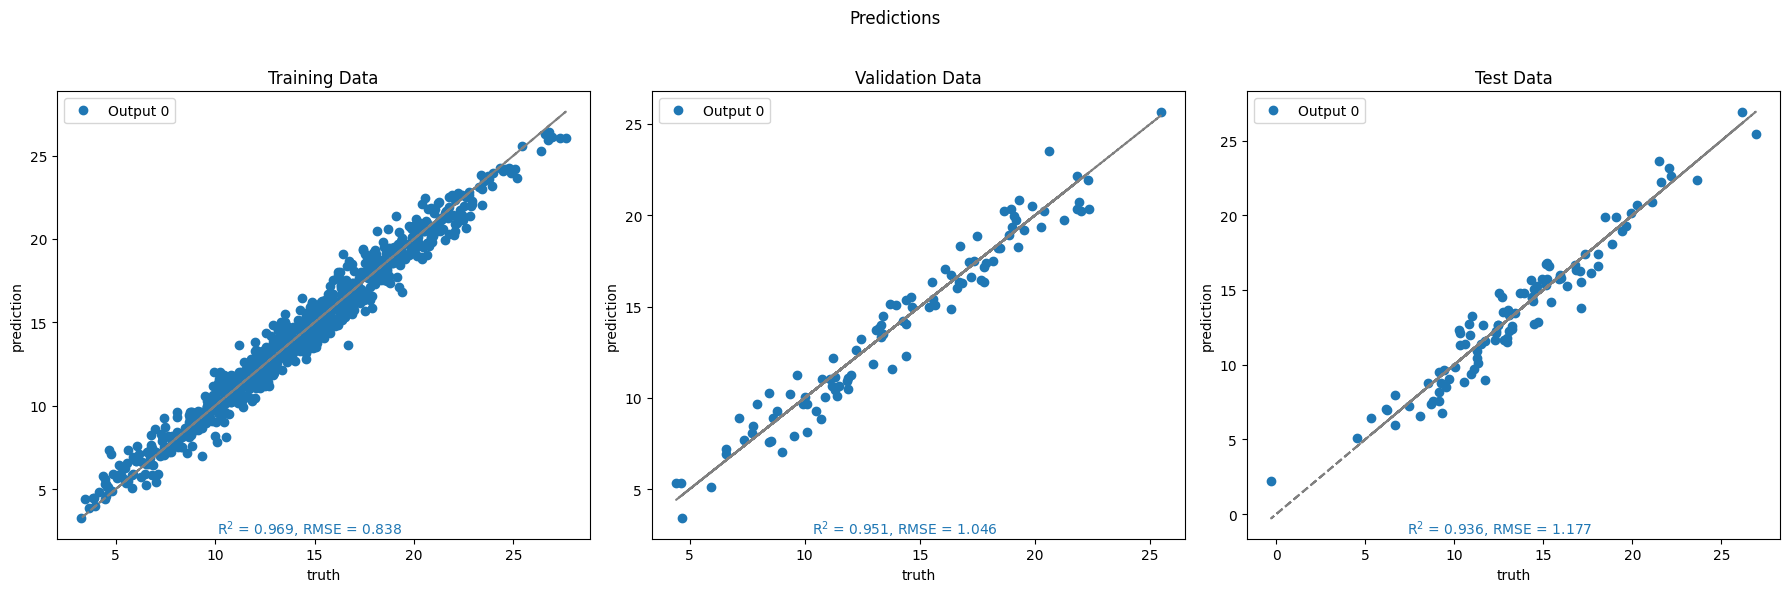

Loading model: model_ae4f9023 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_ae4f9023.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: ann
    l2_reg: 0.001644462086584895
    layer_0_width: 7
    layer_1_width: 5
    best epoch: 307


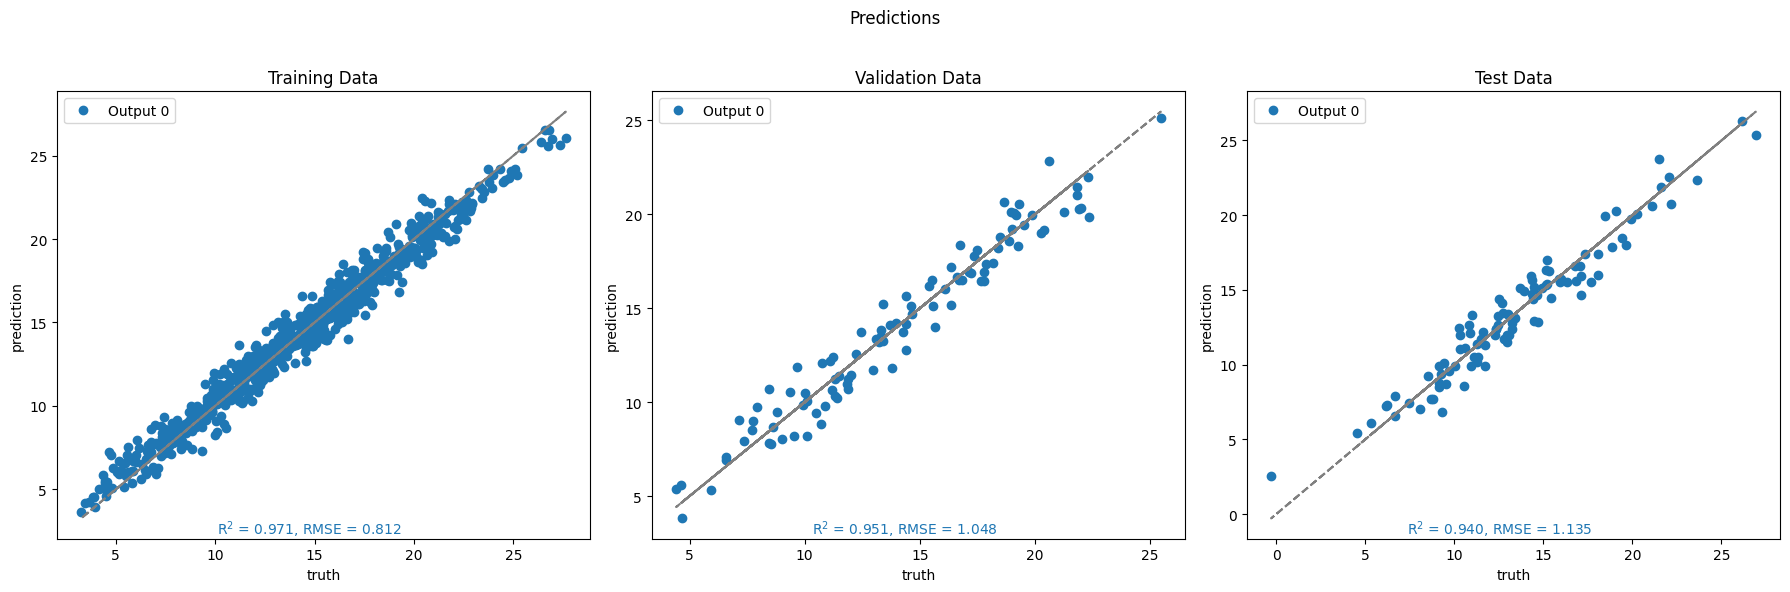

Loading model: model_04cbfae6 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_04cbfae6.pkl
Model hyperparameters:
    act_fun: swish
    arch_type: ann
    l2_reg: 0.0011389096366923698
    layer_0_width: 0
    layer_1_width: 7
    best epoch: 91


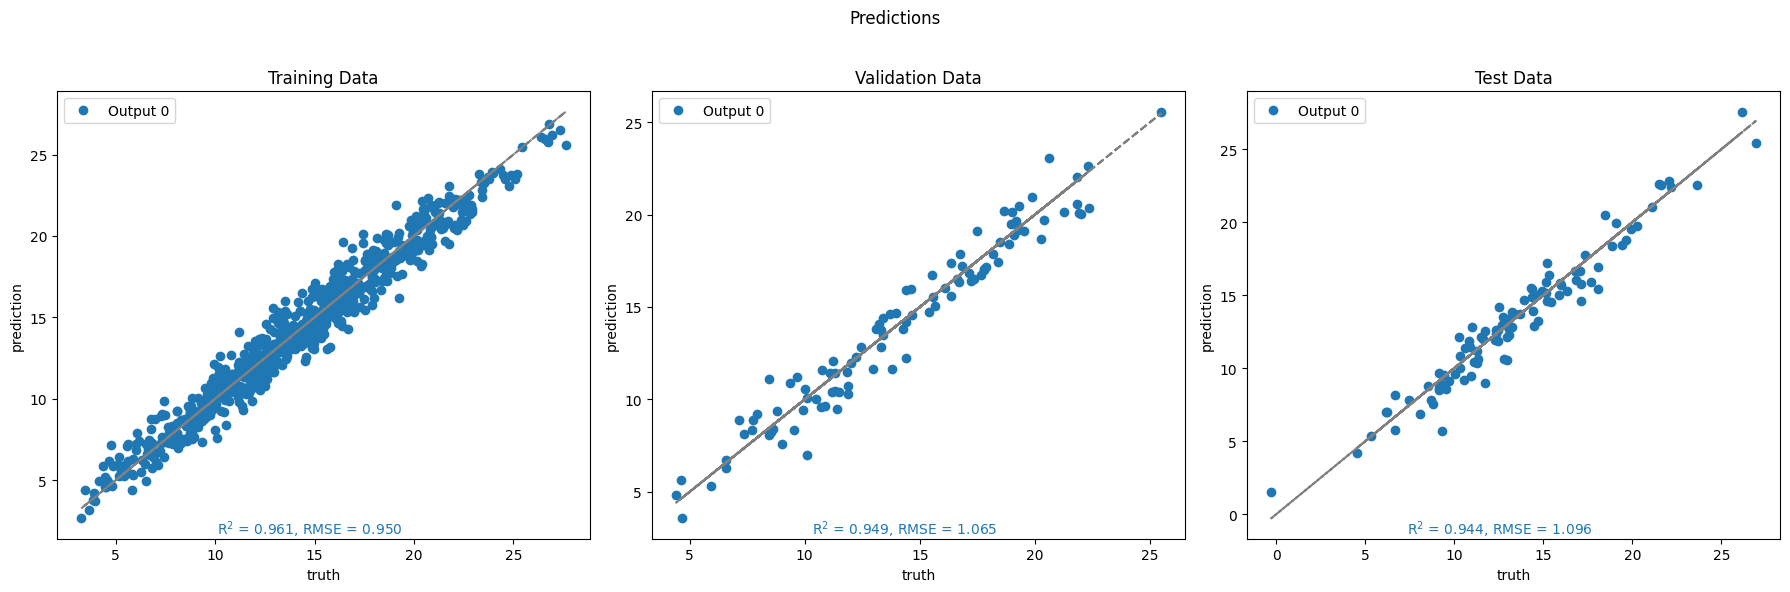

Loading model: model_53818beb from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_53818beb.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: resnet
    l2_reg: 0.0006796578090758161
    layer_0_width: 0
    layer_1_width: 7
    best epoch: 83


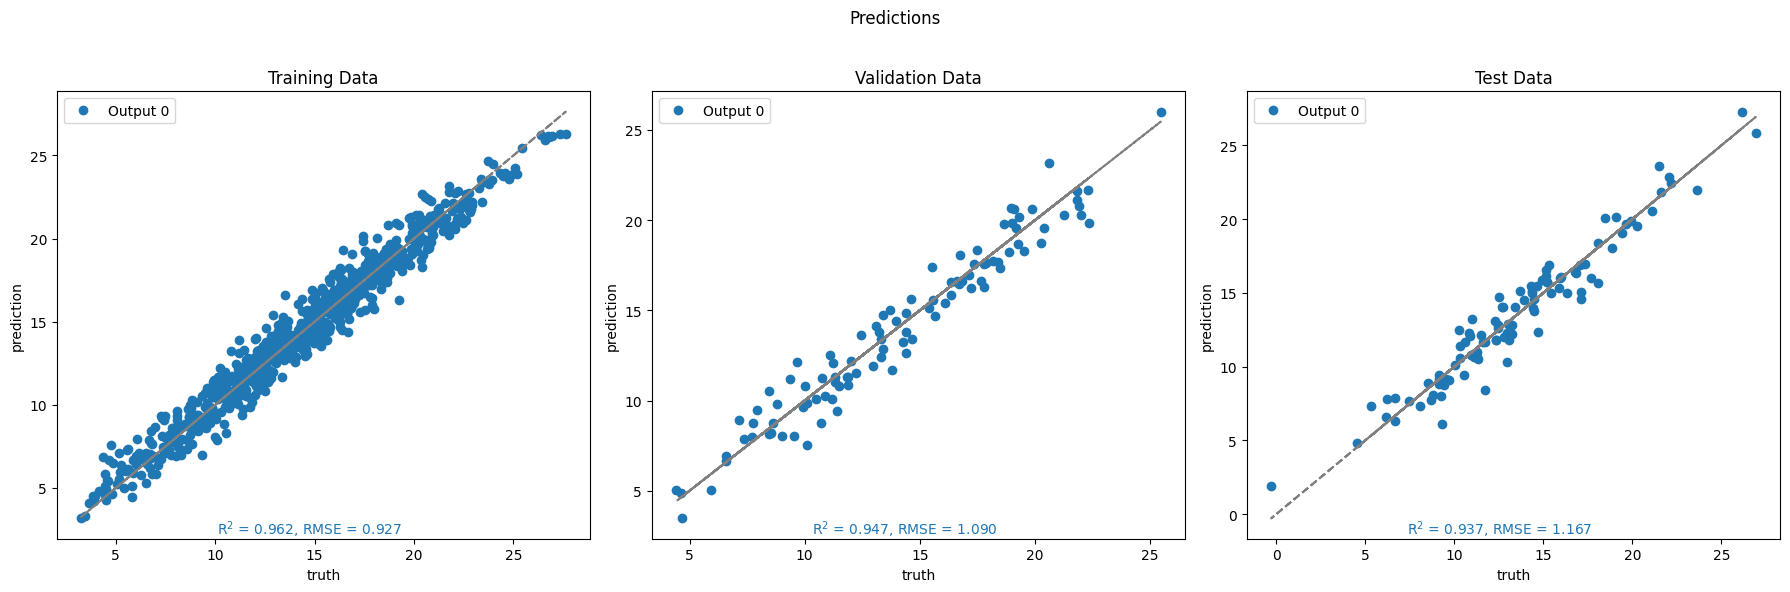

Loading model: model_d9db1d44 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_d9db1d44.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: resnet
    l2_reg: 0.0008660270089918779
    layer_0_width: 0
    layer_1_width: 7
    best epoch: 83


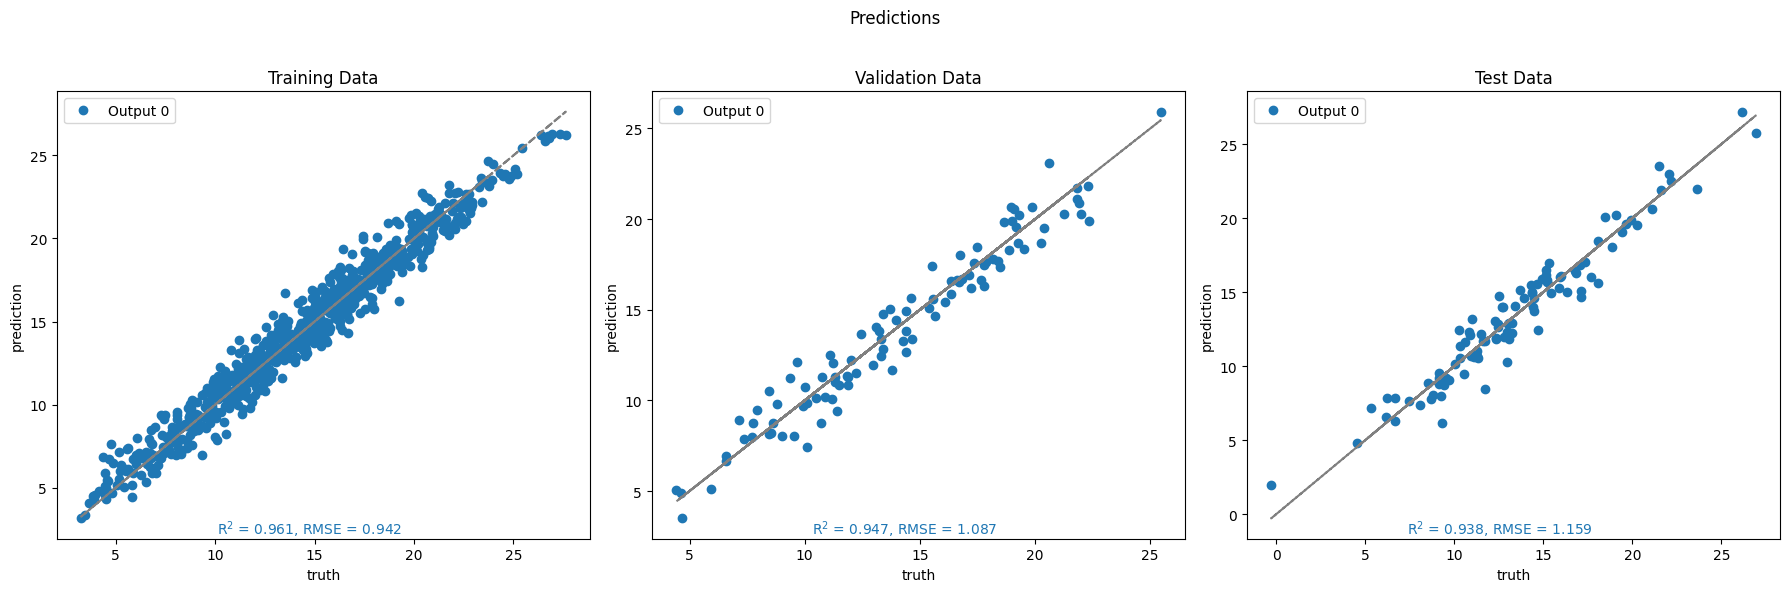

Loading model: model_fc5e0394 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_fc5e0394.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: resnet
    l2_reg: 0.00013106266969080914
    layer_0_width: 0
    layer_1_width: 7
    best epoch: 83


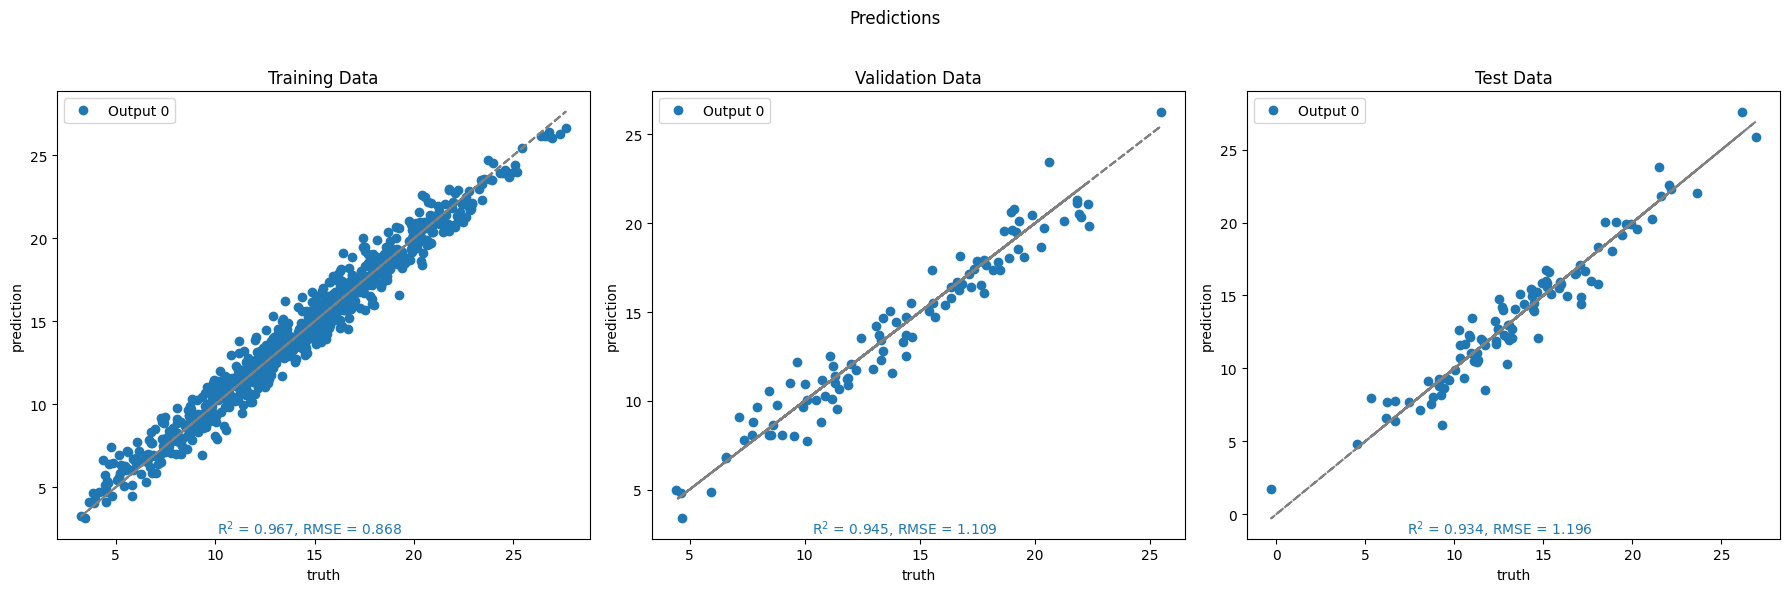

Loading model: model_c49ddf94 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_c49ddf94.pkl
Model hyperparameters:
    act_fun: swish
    arch_type: resnet
    l2_reg: 7.313809935613221e-05
    layer_0_width: 7
    layer_1_width: 5
    best epoch: 37


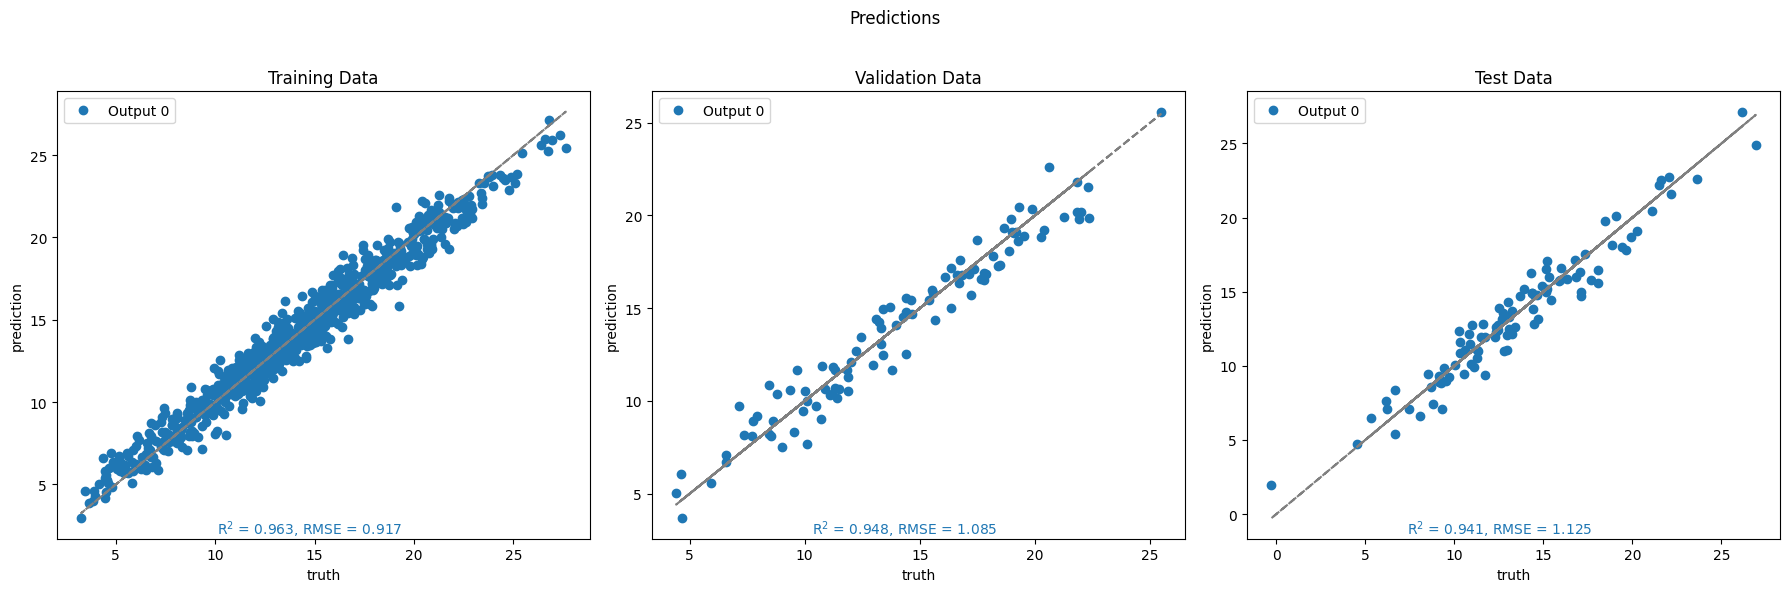

Loading model: model_1d89c13b from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_1d89c13b.pkl
Model hyperparameters:
    act_fun: swish
    arch_type: resnet
    l2_reg: 1.246925225503398e-06
    layer_0_width: 7
    layer_1_width: 7
    best epoch: 67


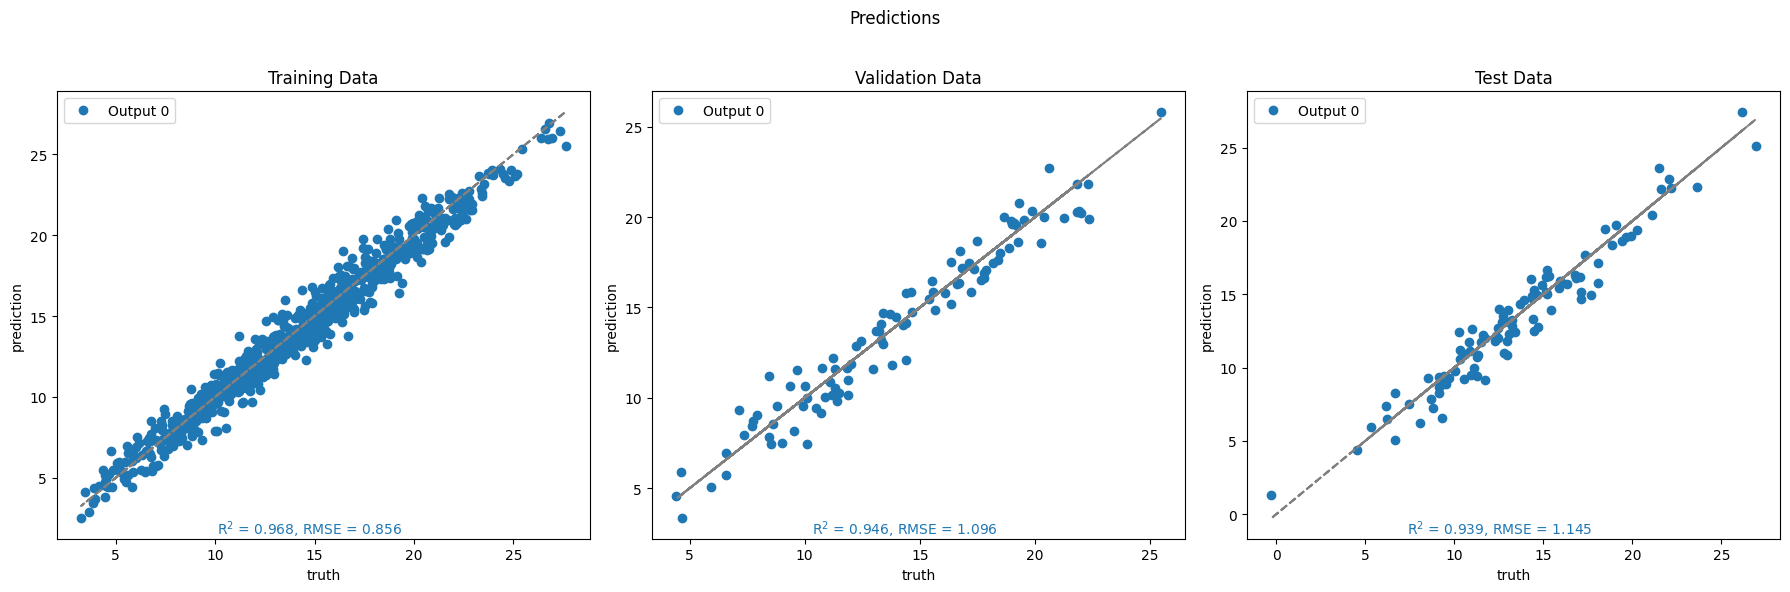

Loading model: model_ef7e5922 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_ef7e5922.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: resnet
    l2_reg: 0.0012248188424140312
    layer_0_width: 0
    layer_1_width: 6
    best epoch: 124


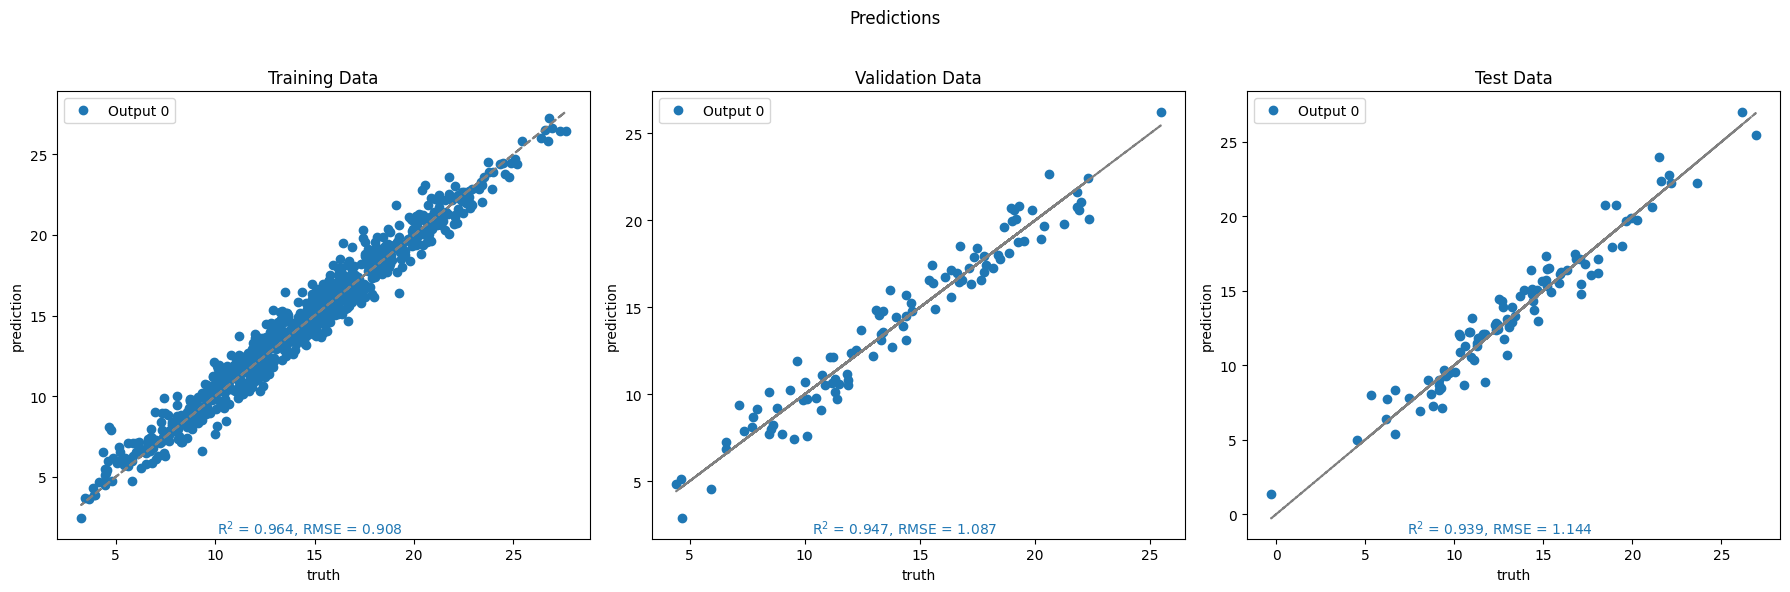

Loading model: model_847ae5a2 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_847ae5a2.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: ann
    l2_reg: 0.0008647796405595979
    layer_0_width: 7
    layer_1_width: 5
    best epoch: 37


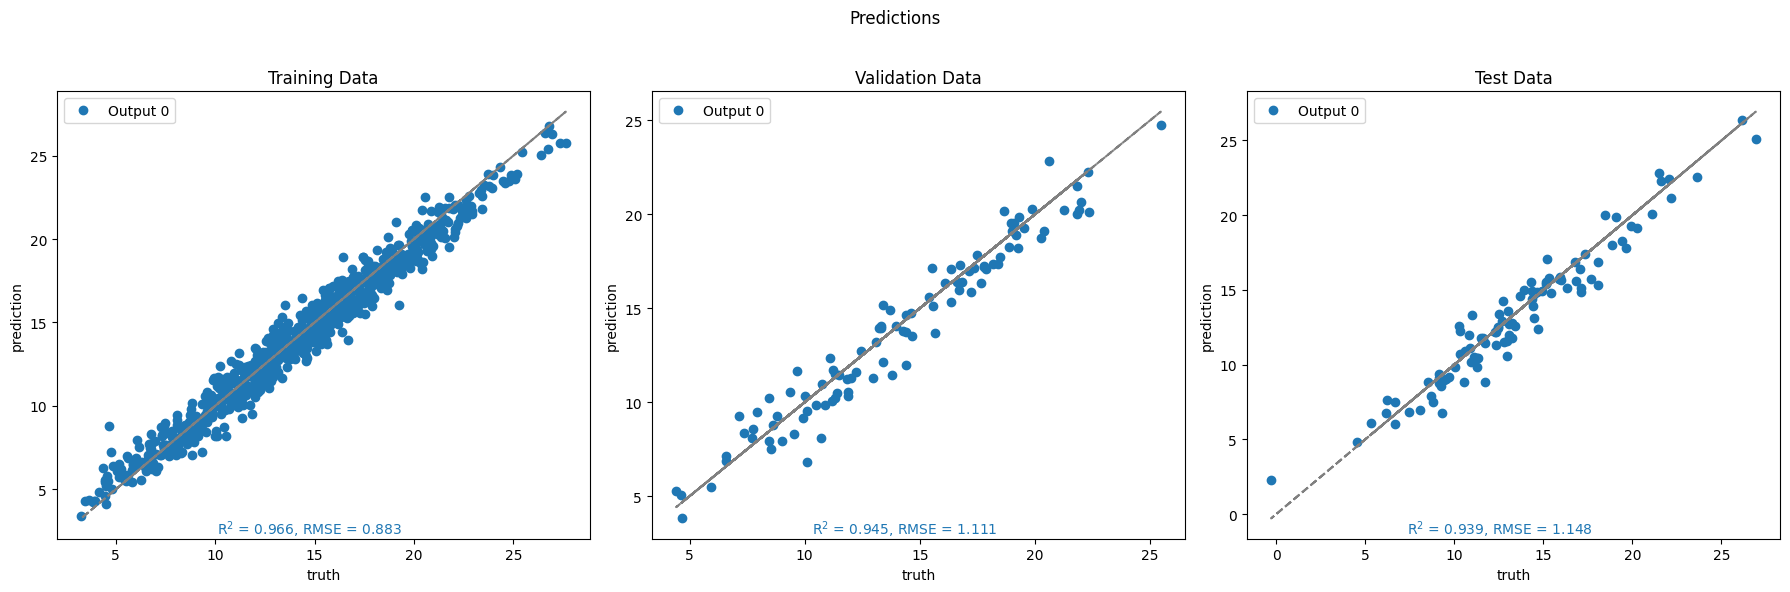

Loading model: model_f094f531 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_f094f531.pkl
Model hyperparameters:
    act_fun: swish
    arch_type: ann
    l2_reg: 0.001834905636020256
    layer_0_width: 7
    layer_1_width: 4
    best epoch: 114


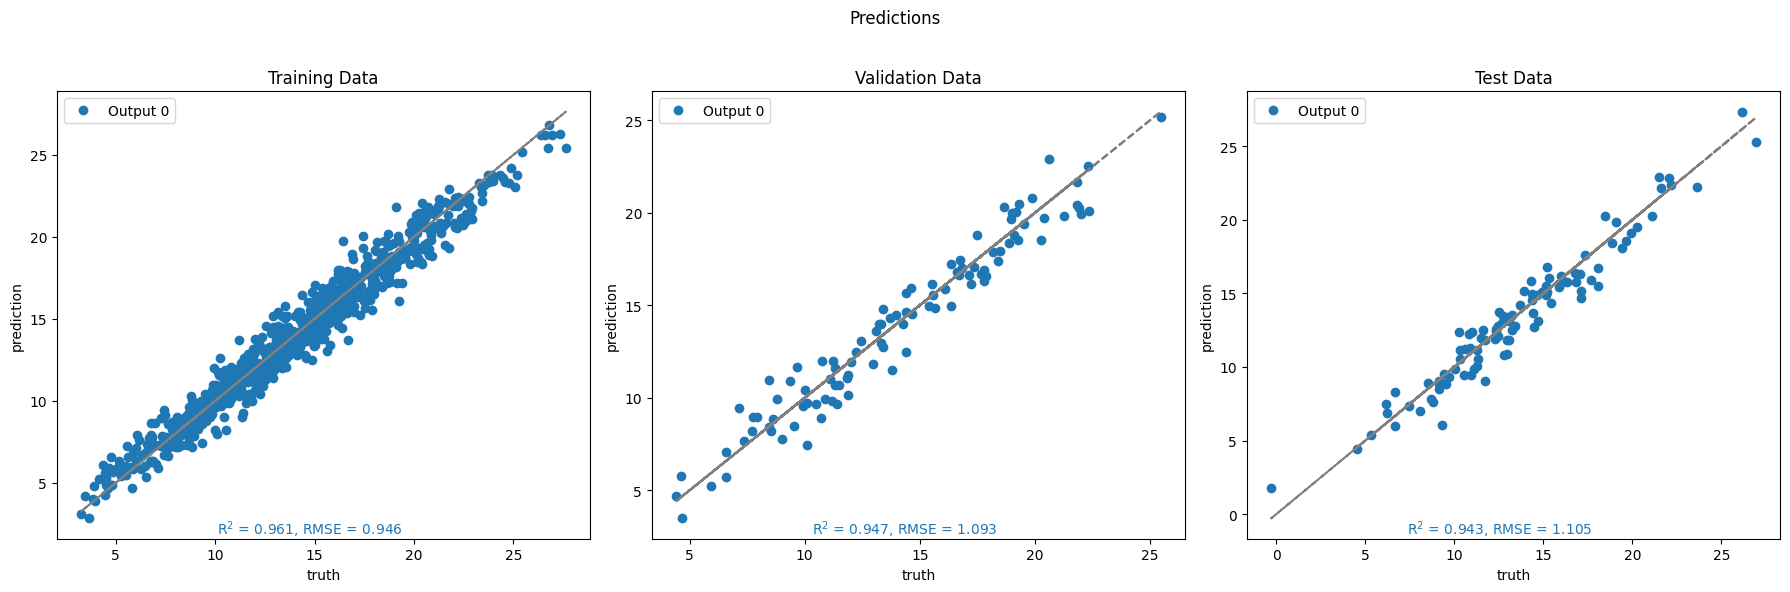

Loading model: model_2cfc9b50 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_2cfc9b50.pkl
Model hyperparameters:
    act_fun: swish
    arch_type: ann
    l2_reg: 7.59873833667185e-06
    layer_0_width: 7
    layer_1_width: 6
    best epoch: 87


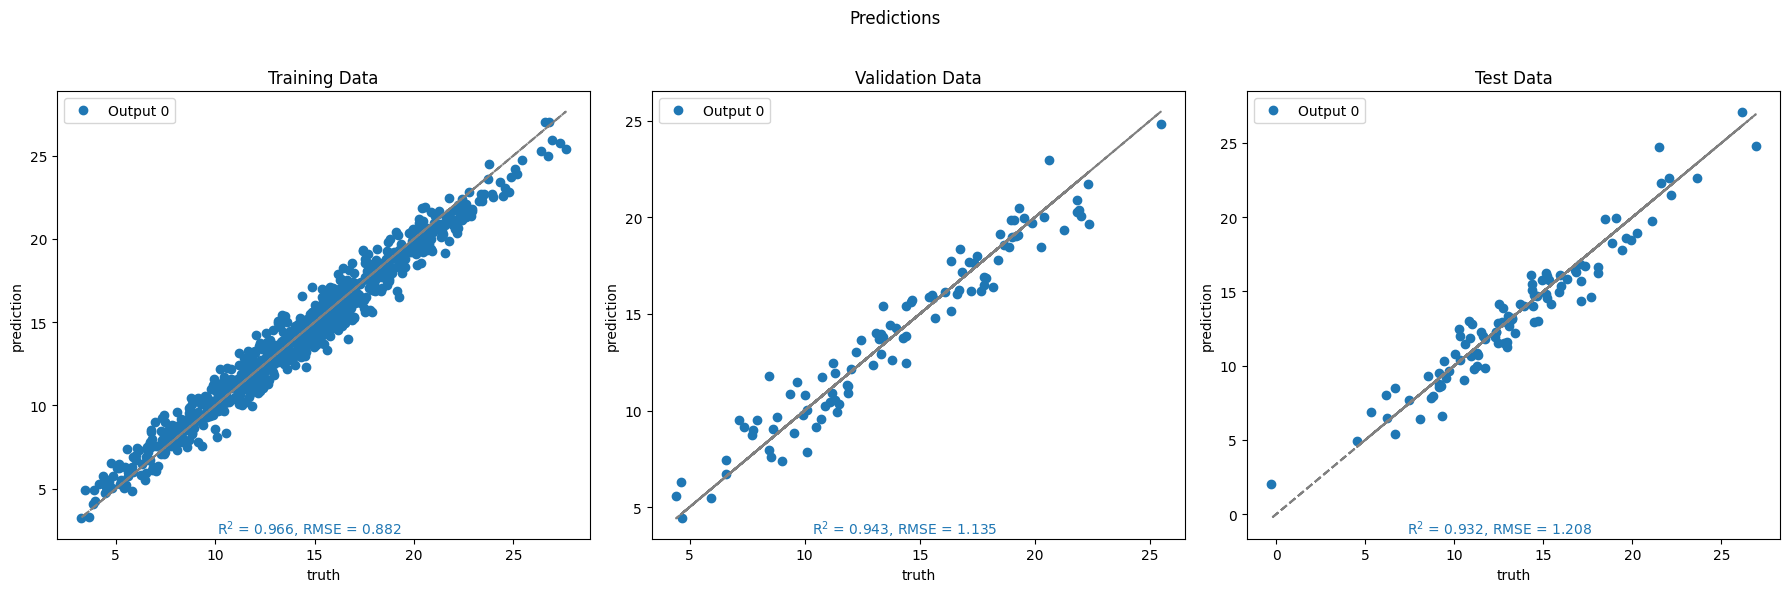

Loading model: model_a2fffedb from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_a2fffedb.pkl
Model hyperparameters:
    act_fun: leaky_relu
    arch_type: ann
    l2_reg: 0.003403172600450759
    layer_0_width: 7
    layer_1_width: 4
    best epoch: 24


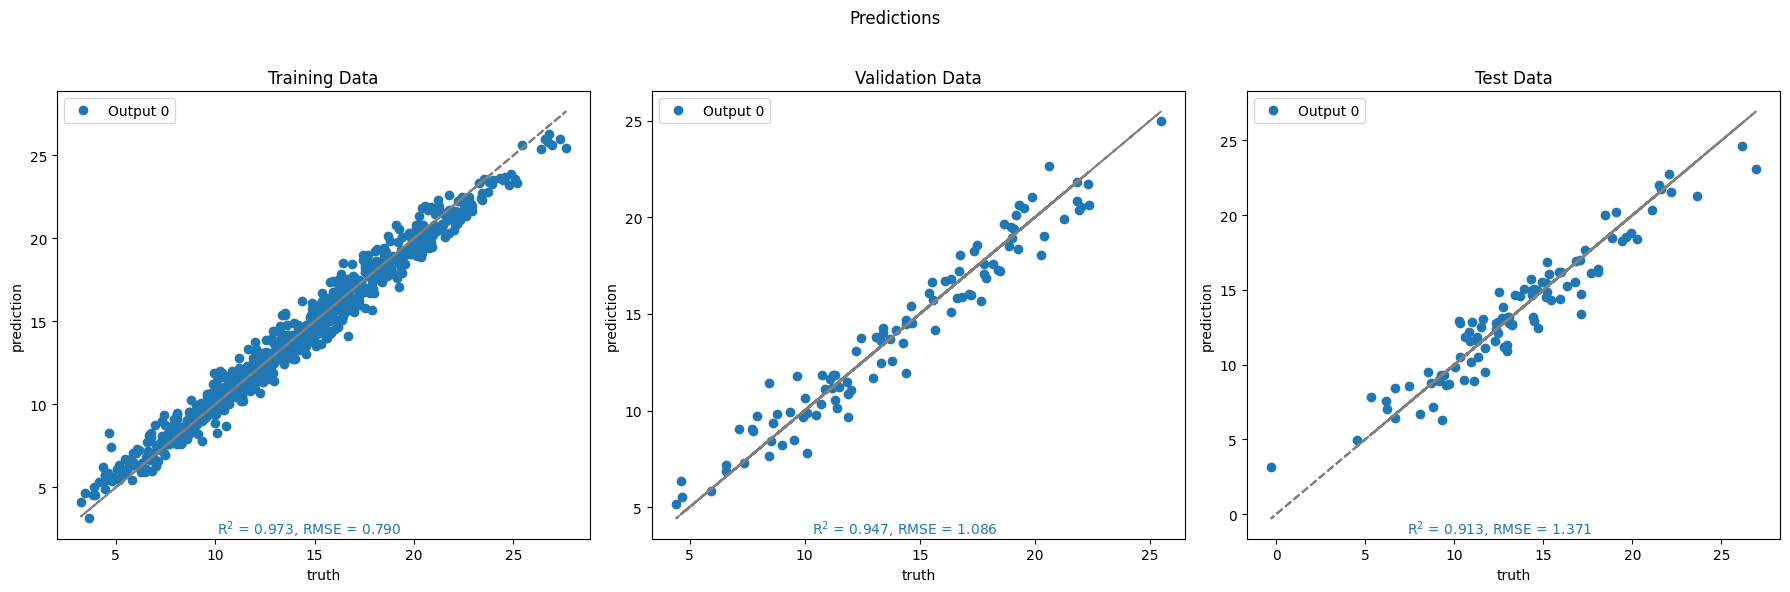

Loading model: model_886f90fa from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_886f90fa.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: ann
    l2_reg: 0.00012296035995808583
    layer_0_width: 7
    layer_1_width: 5
    best epoch: 37


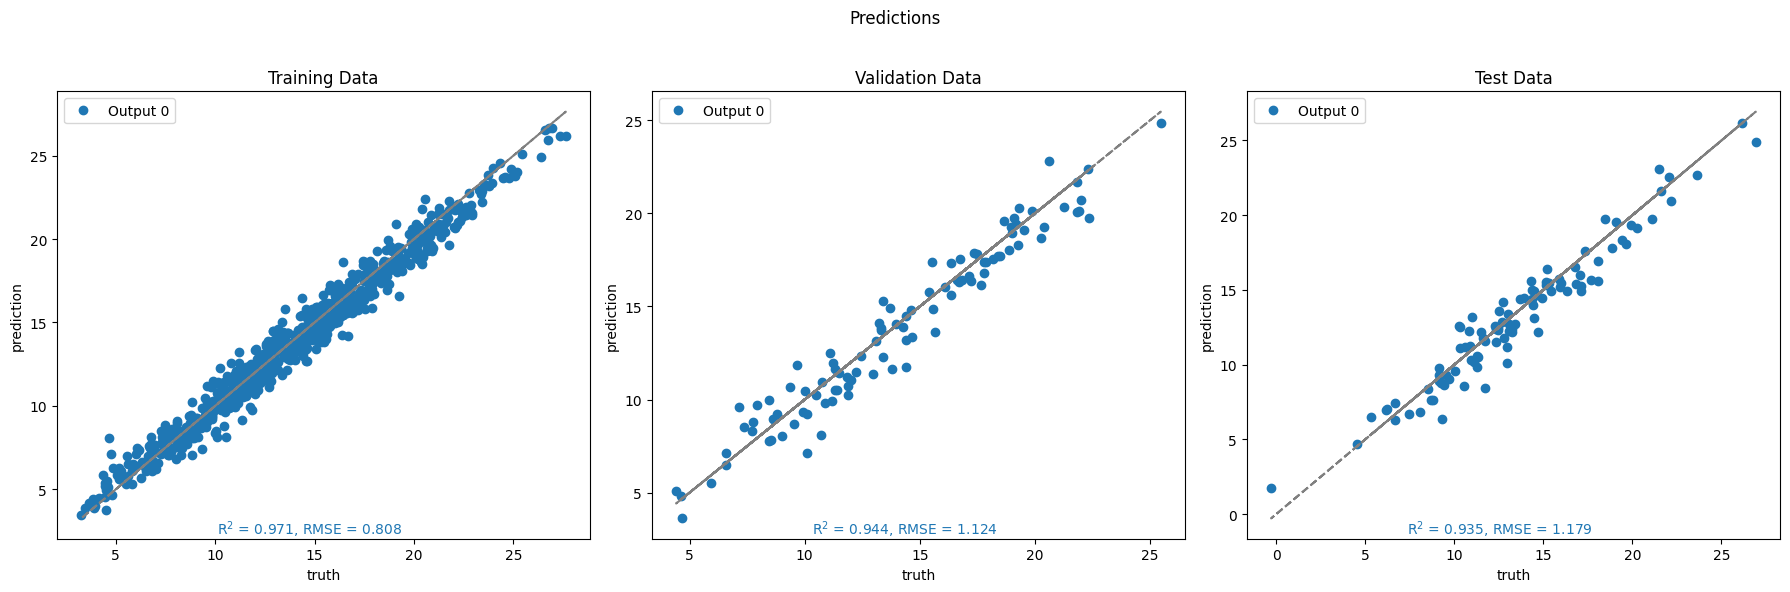

Loading model: model_5a78a99a from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_5a78a99a.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: resnet
    l2_reg: 0.0005384228482390326
    layer_0_width: 0
    layer_1_width: 7
    best epoch: 66


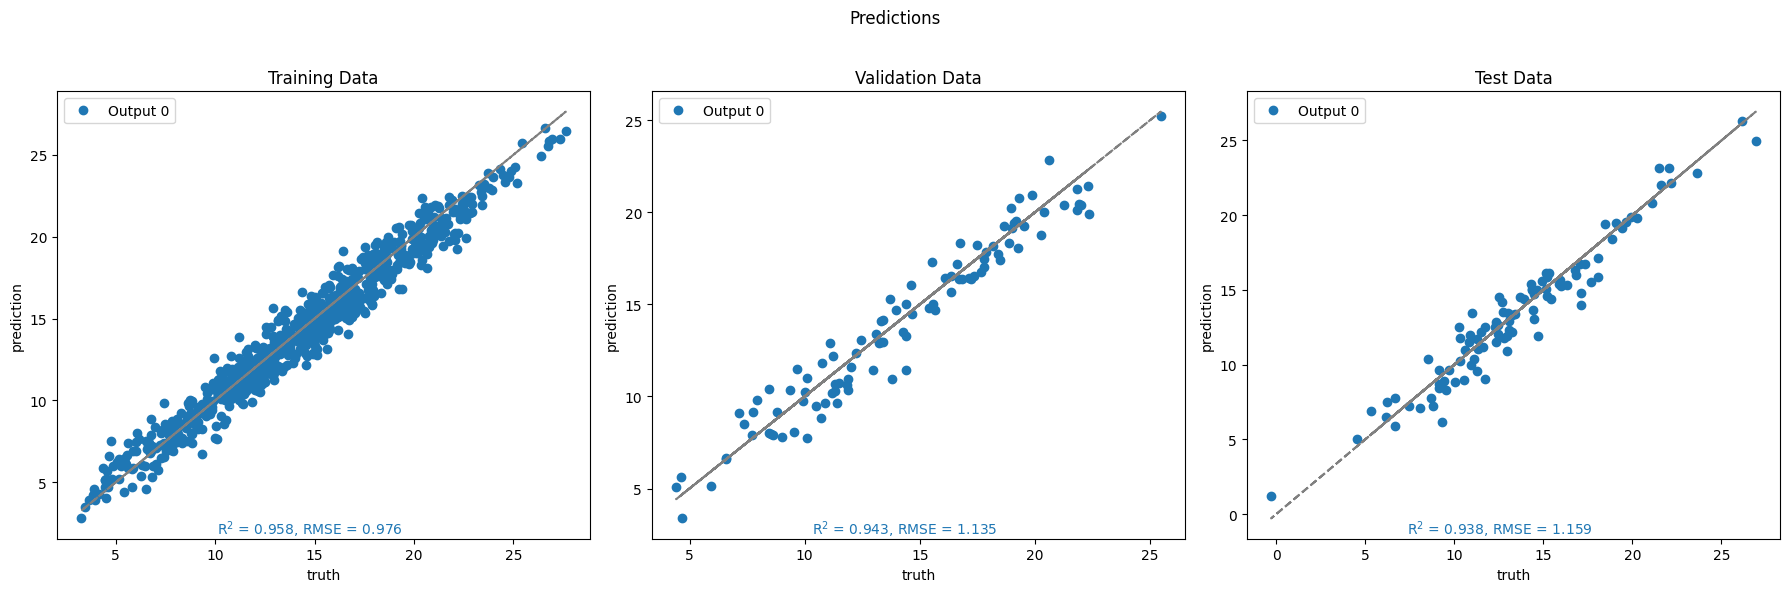

Loading model: model_9c85f8a1 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_9c85f8a1.pkl
Model hyperparameters:
    act_fun: leaky_relu
    arch_type: ann
    l2_reg: 9.390688199464316e-05
    layer_0_width: 0
    layer_1_width: 7
    best epoch: 23


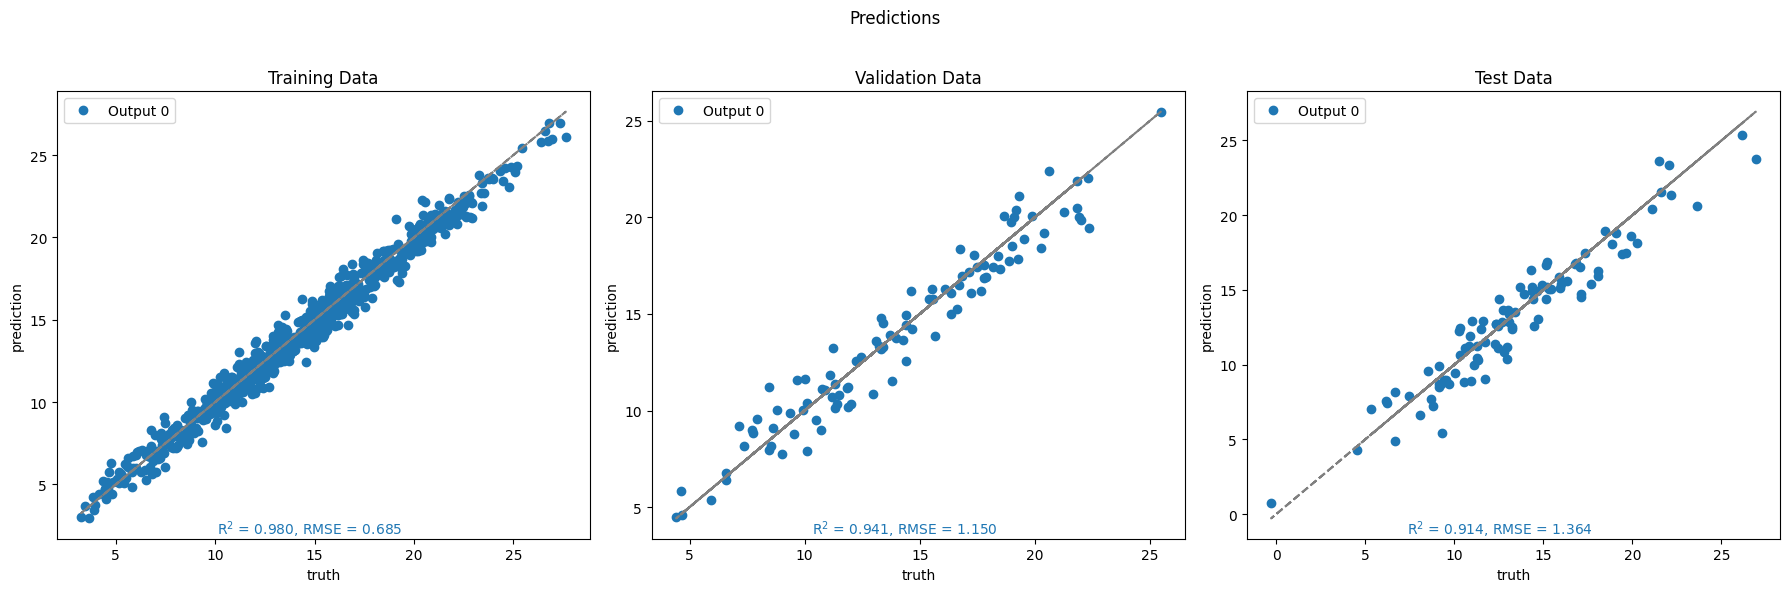

Loading model: model_18659ecb from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_18659ecb.pkl
Model hyperparameters:
    act_fun: tanh
    arch_type: ann
    l2_reg: 0.0005267235045881246
    layer_0_width: 7
    layer_1_width: 6
    best epoch: 41


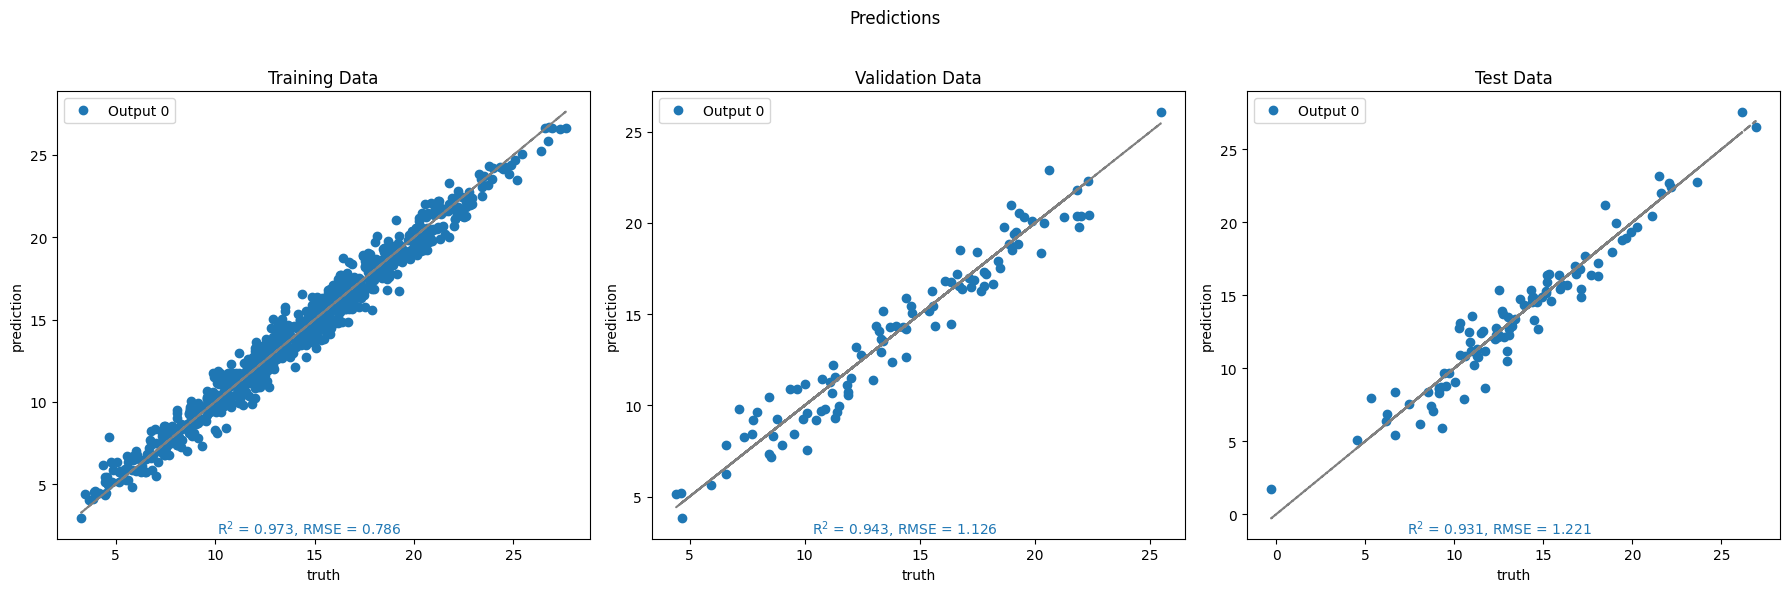

Loading model: model_aaddf476 from /Users/nwimer/NREL_Repos/ai/supervised/regression/outdata/ensemble_results/model_aaddf476.pkl
Model hyperparameters:
    act_fun: swish
    arch_type: resnet
    l2_reg: 1.3288685908383385e-06
    layer_0_width: 7
    layer_1_width: 6
    best epoch: 87


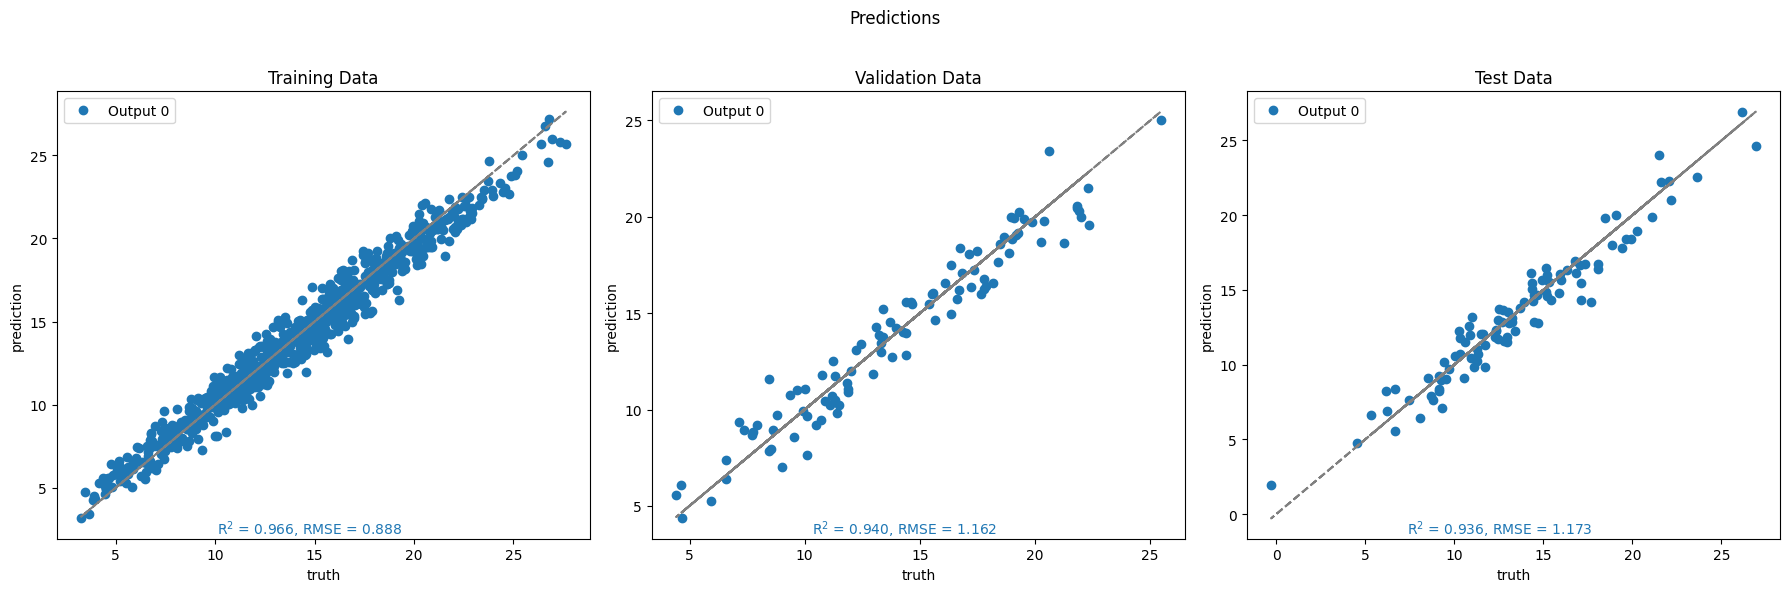

In [23]:
from ptmelt.utils.evaluation import make_predictions
from ptmelt.utils.visualization import plot_predictions

pred_train_ensemble = []
pred_val_ensemble = []
pred_test_ensemble = []

# Load each model and make predictions
for _, row in filtered_models.iterrows():
    model_name = row["model_name"]
    model_path = os.path.join(model_save_dir, f"{model_name}.pkl")
    print(f"Loading model: {model_name} from {model_path}")

    # Load the model configuration
    config_path = os.path.join(model_save_dir, f"{model_name}_config.json")
    with open(config_path, "r") as f:
        model_config = json.load(f)

    print("Model hyperparameters:")
    print(f"    act_fun: {model_config['act_fun']}")
    print(f"    arch_type: {model_config['arch_type']}")
    print(f"    l2_reg: {model_config['l2_reg']}")
    print(f"    layer_0_width: {model_config['layer_0_width']}")
    print(f"    layer_1_width: {model_config['layer_1_width']}")
    print(f"    best epoch: {row['best_epoch']}")

    # Build the model using the saved configuration
    model, _, _ = model_builder(model_config)

    # Load the model weights
    model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))
    model.eval()  # Set the model to evaluation mode

    # Make predictions
    pred_train = make_predictions(
        model,
        x_train,
        y_normalizer=y_normalizer,
        # unnormalize=False,
        unnormalize=True,
    )
    pred_train_ensemble.append(pred_train)
    pred_val = make_predictions(
        model,
        x_val,
        y_normalizer=y_normalizer,
        # unnormalize=False,
        unnormalize=True,
    )
    pred_val_ensemble.append(pred_val)
    pred_test = make_predictions(
        model,
        x_test,
        y_normalizer=y_normalizer,
        # unnormalize=False,
        unnormalize=True,
    )
    pred_test_ensemble.append(pred_test)
    # Plot the predictions
    plot_predictions(
        pred_train, y_train_real, pred_val, y_val_real, pred_test, y_test_real
    )

## Compute Ensemble predictions and visualize the epistemic uncertainty



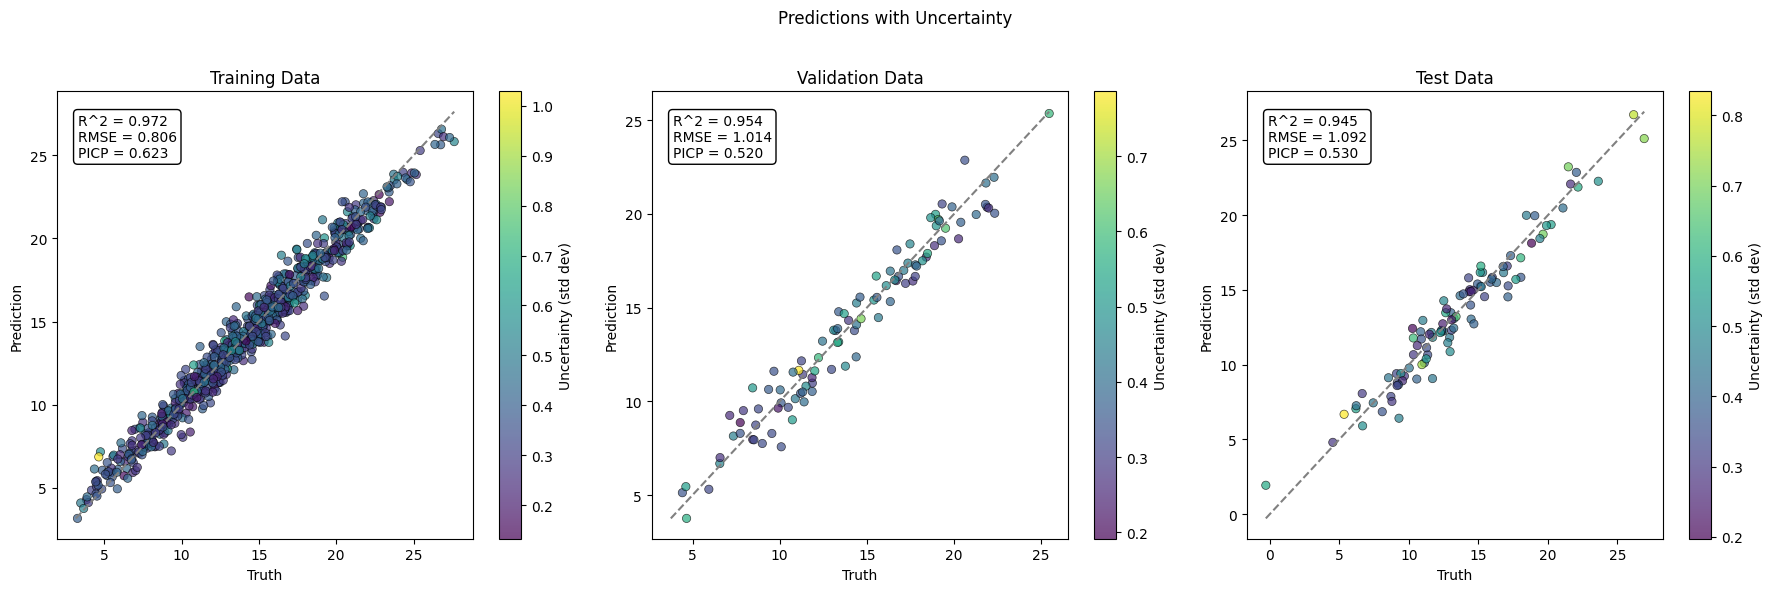

In [24]:
# Compute ensemble predictions with UQ
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Compute the ensemble means
pred_mean_train = np.mean(pred_train_ensemble, axis=0)
pred_mean_val = np.mean(pred_val_ensemble, axis=0)
pred_mean_test = np.mean(pred_test_ensemble, axis=0)
# Compute the standard deviations for uncertainty quantification
pred_std_train = np.std(pred_train_ensemble, axis=0)
pred_std_val = np.std(pred_val_ensemble, axis=0)
pred_std_test = np.std(pred_test_ensemble, axis=0)

plot_predictions_with_uncertainty(
    pred_mean_train,
    pred_std_train,
    y_train_real,
    # y_train,
    pred_mean_val,
    pred_std_val,
    y_val_real,
    # y_val,
    pred_mean_test,
    pred_std_test,
    y_test_real,
    # y_test,
    metrics_to_display=["R^2", "RMSE", "PICP"],
)

## Plot the predictions in physical space with uncertainties

/var/folders/jb/yy7lxgjd6915xnjb4_b6npk05gvryg/T/ipykernel_82896/2209725963.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


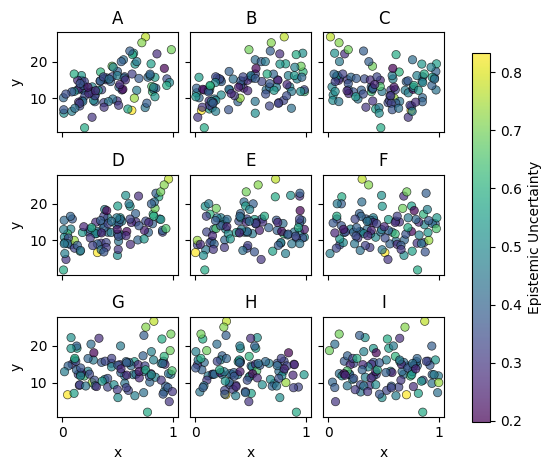

In [25]:
# Make a mosaic plot of the predictions colored by uncertainty

# Visualize the data using a mosaic plot
mosaic = [["A", "B", "C"], ["D", "E", "F"], ["G", "H", "I"]]
fig, axdict = plt.subplot_mosaic(mosaic, sharex=True, sharey=True)
# Loop over all the labels in the mosaic
for idx, ilabel in enumerate(axdict.keys()):
    sc = axdict[ilabel].scatter(
        x_test_real[:, idx],
        pred_mean_test,
        c=pred_std_test,
        # marker="*",
        # linestyle="None",
        cmap="viridis",
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5,
    )
    # Set some plot labels
    axdict[ilabel].set_title(ilabel)
    if ilabel in ["A", "D", "G"]:
        axdict[ilabel].set_ylabel("y")
    if ilabel in ["G", "H", "I"]:
        axdict[ilabel].set_xlabel("x")

# Add a colorbar to the figure
cbar = fig.colorbar(
    sc, ax=axdict.values(), orientation="vertical", fraction=0.2, pad=-0.55
)
cbar.set_label("Epistemic Uncertainty")

# fig.suptitle("Test Datset predictions with Epistemic Uncertainty")
fig.tight_layout()
plt.show()

# End